# Tavily + Oracle AI Database Demo
## Fresh Web Retrieval with Persistent Oracle Memory

This notebook demonstrates the Oracle-backed Tavily hybrid retrieval implementation in this repository. The integration turns Tavily search results into durable Oracle memory: Tavily retrieves fresh external knowledge, and Oracle stores the retrieved content, embeddings, raw payloads, and provenance so future AI workflows can reuse it.

**Core idea**

- Tavily provides fresh search results from the web.
- Oracle stores retrieved knowledge as persistent memory.
- Oracle enables cache reuse, semantic search, deduplication, JSON provenance, and vector indexing.
- Together, Tavily and Oracle form an AI-ready retrieval layer for RAG systems and agentic applications.

## Index

| Section | What it covers |
|---------|----------------|
| [Problem Statement](#Problem-Statement) | Why Tavily freshness needs an Oracle memory layer |
| [Architecture Overview](#Architecture-Overview) | The shared Oracle-first flow across retrieval modes |
| [Why Oracle](#Why-Oracle) | Oracle-specific persistence, vector, JSON, and provenance value |
| [Setup and Prerequisites](#Setup-and-Prerequisites) | Required services, packages, and environment variables |
| [Oracle Connection](#Oracle-Connection) | Database connection setup for the hybrid client |
| [Schema and Table Setup](#Schema-and-Table-Setup) | Table columns, optional metadata, and index setup |
| [Initialize Tavily and Oracle Clients](#Initialize-Tavily-and-Oracle-Clients) | Client configuration for all three retrieval modes |
| [Mode 1: Hybrid Search](#Mode-1:-Hybrid-Search) | Oracle memory plus fresh Tavily retrieval and reranking |
| [Mode 2: Cache-Only Search](#Mode-2:-Cache-Only-Search) | TTL-aware Oracle cache reuse |
| [Mode 3: Cache-Then-Memory Search](#Mode-3:-Cache-Then-Memory-Search) | Fresh cache, durable memory, then Tavily fallback |
| [Compare All Retrieval Modes](#Compare-All-Retrieval-Modes) | When to choose each retrieval strategy |
| [Agentic AI Use Case](#Agentic-AI-Use-Case) | A minimal agent-style retrieval helper |
| [Cleanup and Optional Reset](#Cleanup-and-Optional-Reset) | Optional demo data cleanup |
| [Summary](#Summary) | Key takeaways |

## Problem Statement

![Problem statement](images/Problem_statement.png)

This notebook frames Tavily as the freshness layer and Oracle as the durable memory layer. The code below demonstrates how `TavilyHybridClient` persists, reuses, and audits Tavily results through Oracle-backed retrieval modes.

## Architecture Overview

![Architecture overview](images/Architecture.png)

The shared entry point embeds the query, checks Oracle, and calls Tavily only when the selected mode needs fresh external results. Later cells run the three paths against the same Oracle table so the differences show up in result origins, cache behavior, and persistence.

## Why Oracle

![Why Oracle](images/Why_oracle.png)

Oracle adds durable, queryable, enterprise-grade memory to Tavily retrieval by storing vectors, raw JSON payloads, provenance metadata, cache timestamps, memory lifecycle fields, and vector index configuration alongside retrieved content.

## Setup and Prerequisites

**Environment:** this notebook can run in two modes.

- **Real Oracle mode:** uses a reachable Oracle Database as the durable Tavily memory backend.
- **Demo fallback mode:** if Oracle connection settings are missing or the listener is unreachable, the notebook uses an in-memory Oracle-shaped fallback so Tavily customers can still run the walkthrough.

**Docker is not required.** It is only the easiest way to run Oracle Free/23ai locally. If you already have Oracle AI Database, Oracle Database 23ai, Oracle Free, or Autonomous Database available, point `ORACLE_DSN` and the wallet settings at that database. If you use the default local DSN, `localhost:1521/FREEPDB1`, then you need a running Oracle container or another local Oracle listener publishing port `1521`.

**Fallback limitations:** the in-memory fallback is for notebook demonstration only. It does not validate Oracle SQL execution, VECTOR indexes, Oracle Text indexes, JSON storage, transaction behavior, or durable persistence. Set `ORACLE_REQUIRE_REAL_DB=1` to disable fallback and fail fast unless a real Oracle connection succeeds.

**Base prerequisites**

- A Python environment with this repository installed or available on `PYTHONPATH`.
- A Tavily API key in `TAVILY_API_KEY`.
- `python-oracledb`, available through `python -m pip install -e ".[oracle]"` from this repository.

**Real Oracle prerequisites**

- Oracle Database 23ai or a compatible Oracle Database with `VECTOR` support.
- An Oracle user/schema with permission to create or alter the demo table.
- Optional Oracle Text privileges if you want native hybrid vector + text retrieval.
- Optional Oracle wallet/mTLS configuration for Autonomous Database connections.

**Embedding and ranking:** the default `TavilyHybridClient` helpers use Cohere when no custom functions are supplied. To keep this notebook limited to Tavily + Oracle services, the code below provides a deterministic local embedding function and a score-based ranking function through the client extension points. In production, replace those helpers with the embedding and reranking models used by your AI application.

**Required environment variables**

- `TAVILY_API_KEY`

**Required for real Oracle mode**

- `ORACLE_USER`
- `ORACLE_PASSWORD`
- `ORACLE_DSN`

**Optional environment variables used by the demo**

| Variable | Purpose |
|----------|---------|
| `ORACLE_REQUIRE_REAL_DB=1` | Disable the in-memory fallback and require a real Oracle connection |
| `ORACLE_VECTOR_TABLE` | Defaults to `TAVILY_DOCUMENTS` |
| `ORACLE_CONTENT_FIELD` | Defaults to `CONTENT` |
| `ORACLE_EMBEDDINGS_FIELD` | Defaults to `EMBEDDINGS` |
| `ORACLE_VECTOR_DIMENSION` | Defaults to `1024`; set it to match an existing table's `VECTOR` dimension |
| `ORACLE_CACHE_TTL_SECONDS`, `ORACLE_CACHE_SCORE_THRESHOLD`, `ORACLE_MEMORY_SCORE_THRESHOLD`, `ORACLE_MEMORY_MAX_RESULTS` | Tune cache and memory mode behavior |
| `ORACLE_SYSDBA=1` | Connects with `AUTH_MODE_SYSDBA` when needed locally |
| `ORACLE_CONFIG_DIR`, `ORACLE_WALLET_LOCATION`, `ORACLE_WALLET_PASSWORD` | Configure wallet-based connections |
| `TAVILY_LOAD_PROXY_ENV=1` | Opt in to loading `HTTP_PROXY`, `HTTPS_PROXY`, `ALL_PROXY`, and `NO_PROXY` from `.env` for corporate proxy environments |


In [1]:
import hashlib
import json
import math
import os
import re
import socket
from collections import Counter
from datetime import datetime, timedelta, timezone
from textwrap import shorten
from urllib.parse import urlparse

try:
    import oracledb
except ImportError as exc:
    raise RuntimeError(
        "python-oracledb is required for this notebook. Install it with "
        "`python -m pip install -e \".[oracle]\"` or `python -m pip install oracledb`."
    ) from exc

try:
    from IPython.display import display as notebook_display
except ImportError:
    notebook_display = None

from tavily import TavilyClient, TavilyHybridClient
from tavily.databases import oracledb as tavily_oracle_db

PROXY_ENV_VAR_NAMES = {"HTTP_PROXY", "HTTPS_PROXY", "ALL_PROXY", "NO_PROXY"}
PROXY_OPT_IN_ENV_VAR_NAMES = {"TAVILY_LOAD_PROXY_ENV", "ORACLE_LOAD_PROXY_ENV"}


def is_truthy_env(value):
    return str(value).strip().lower() in {"1", "true", "yes", "y", "on"}


def load_local_env(paths=(".env", "../.env")):
    for path in paths:
        if not os.path.exists(path):
            continue

        entries = []
        with open(path, encoding="utf-8") as env_file:
            for raw_line in env_file:
                line = raw_line.strip()
                if not line or line.startswith("#") or "=" not in line:
                    continue
                key, value = line.split("=", 1)
                key = key.strip()
                value = value.strip().strip('"').strip("'")
                if value:
                    entries.append((key, value))

        load_proxy_env = any(
            is_truthy_env(os.environ.get(name)) for name in PROXY_OPT_IN_ENV_VAR_NAMES
        ) or any(
            key.upper() in PROXY_OPT_IN_ENV_VAR_NAMES and is_truthy_env(value)
            for key, value in entries
        )

        for key, value in entries:
            if key.upper() in PROXY_ENV_VAR_NAMES:
                if load_proxy_env:
                    os.environ[key] = value
                else:
                    for env_key in {key, key.upper(), key.lower()}:
                        if os.environ.get(env_key) == value:
                            os.environ.pop(env_key, None)
                continue

            if key.startswith("ORACLE_"):
                os.environ[key] = value
            else:
                os.environ.setdefault(key, value)


load_local_env()

REQUIRED_ENV_VARS = ["TAVILY_API_KEY"]
missing = [name for name in REQUIRED_ENV_VARS if not os.environ.get(name)]
if missing:
    raise RuntimeError(
        "Missing required environment variables: "
        + ", ".join(missing)
        + ". Set them before running the notebook."
    )

ORACLE_REQUIRE_REAL_DB = is_truthy_env(os.environ.get("ORACLE_REQUIRE_REAL_DB"))
ORACLE_REQUIRED_ENV_VARS = ["ORACLE_USER", "ORACLE_PASSWORD", "ORACLE_DSN"]
missing_oracle_env = [name for name in ORACLE_REQUIRED_ENV_VARS if not os.environ.get(name)]
ORACLE_DEMO_FALLBACK = bool(missing_oracle_env)

if missing_oracle_env and ORACLE_REQUIRE_REAL_DB:
    raise RuntimeError(
        "Missing Oracle environment variables while ORACLE_REQUIRE_REAL_DB=1: "
        + ", ".join(missing_oracle_env)
    )

if ORACLE_DEMO_FALLBACK:
    os.environ.setdefault("ORACLE_USER", "TAVILY_DEMO")
    os.environ.setdefault("ORACLE_PASSWORD", "demo_password")
    os.environ.setdefault("ORACLE_DSN", "localhost:1521/FREEPDB1")

TABLE_NAME = tavily_oracle_db.validate_identifier(
    os.environ.get("ORACLE_VECTOR_TABLE", "TAVILY_DOCUMENTS"),
    "ORACLE_VECTOR_TABLE",
)
CONTENT_FIELD = tavily_oracle_db.validate_identifier(
    os.environ.get("ORACLE_CONTENT_FIELD", "CONTENT"),
    "ORACLE_CONTENT_FIELD",
)
EMBEDDINGS_FIELD = tavily_oracle_db.validate_identifier(
    os.environ.get("ORACLE_EMBEDDINGS_FIELD", "EMBEDDINGS"),
    "ORACLE_EMBEDDINGS_FIELD",
)
CACHE_TIMESTAMP_FIELD = tavily_oracle_db.validate_identifier(
    os.environ.get("ORACLE_CACHE_TIMESTAMP_FIELD", "ADDED_AT"),
    "ORACLE_CACHE_TIMESTAMP_FIELD",
)
VECTOR_INDEX_NAME = tavily_oracle_db.validate_identifier(
    os.environ.get("ORACLE_VECTOR_INDEX_NAME", "TAVILY_DOCS_VEC_IDX"),
    "ORACLE_VECTOR_INDEX_NAME",
)
TEXT_INDEX_NAME = tavily_oracle_db.validate_identifier(
    os.environ.get("ORACLE_TEXT_INDEX_NAME", "TAVILY_DOCS_TEXT_IDX"),
    "ORACLE_TEXT_INDEX_NAME",
)

EMBEDDING_DIMENSION = int(os.environ.get("ORACLE_VECTOR_DIMENSION", "1024"))
if EMBEDDING_DIMENSION < 16:
    raise ValueError("ORACLE_VECTOR_DIMENSION must be at least 16 for this demo embedding function.")

FEATURES = {
    "oracle": 0,
    "database": 0,
    "vector": 1,
    "search": 2,
    "json": 3,
    "provenance": 4,
    "cache": 5,
    "freshness": 6,
    "tavily": 7,
    "agent": 8,
    "rag": 9,
    "memory": 10,
    "deduplication": 11,
    "index": 12,
    "ai": 13,
    "web": 14,
    "hybrid": 15,
}
SYNONYMS = {
    "23ai": "ai",
    "db": "database",
    "semantic": "vector",
    "similarity": "vector",
    "retrieval": "search",
    "retrieve": "search",
    "cached": "cache",
    "fresh": "freshness",
    "source": "provenance",
    "sources": "provenance",
    "dedup": "deduplication",
    "duplicate": "deduplication",
    "duplicates": "deduplication",
    "hnsw": "index",
    "ivf": "index",
    "agents": "agent",
}
TOKEN_RE = re.compile(r"[a-z0-9]+")


def demo_embedding_function(texts, input_type):
    """Small deterministic embedding helper for the demo notebook.

    The repository API accepts any embedding callable with this signature. This
    local helper keeps the notebook limited to Tavily + Oracle services while
    still exercising Oracle VECTOR storage, search, and deduplication.
    """
    vectors = []
    for text in texts:
        vector = [0.0] * EMBEDDING_DIMENSION
        for token in TOKEN_RE.findall(str(text).lower()):
            token = SYNONYMS.get(token, token)
            if token in FEATURES:
                vector[FEATURES[token] % EMBEDDING_DIMENSION] += 1.0
            else:
                digest = hashlib.sha256(token.encode("utf-8")).hexdigest()
                bucket = int(digest[:8], 16) % EMBEDDING_DIMENSION
                vector[bucket] += 0.15

        norm = math.sqrt(sum(value * value for value in vector))
        if norm == 0:
            vector[0] = 1.0
            norm = 1.0
        vectors.append([value / norm for value in vector])
    return vectors


def score_ranking_function(query, documents, top_n):
    """Rank the merged Oracle + Tavily result shape without external services."""
    return sorted(
        documents,
        key=lambda document: float(document.get("score") or 0.0),
        reverse=True,
    )[:top_n]


def summarize_results(results, title="Results", limit=5):
    print(title)
    print("-" * len(title))
    print(f"result_count={len(results)} origins={dict(Counter(result.get('origin') for result in results))}")
    for index, result in enumerate(results[:limit], start=1):
        score = result.get("score")
        score_text = f"{float(score):.4f}" if score is not None else "n/a"
        snippet = shorten(str(result.get("content", "")).replace("\n", " "), width=240, placeholder="...")
        url = result.get("url", "not included in hybrid result shape; inspect Oracle provenance")
        print(f"{index}. origin={result.get('origin')} score={score_text}")
        print(f"   url={url}")
        print(f"   snippet={snippet}")


def display_rows(rows, title=None):
    if title:
        print(title)
    if not rows:
        print("No rows returned.")
        return
    if notebook_display:
        notebook_display(rows)
    else:
        print(json.dumps(rows, default=str, indent=2))


def parse_oracle_dsn_address(dsn):
    dsn = str(dsn or "").strip()
    if not dsn:
        return None

    if dsn.startswith("("):
        host_match = re.search(r"HOST\s*=\s*([^\)]+)", dsn, re.IGNORECASE)
        port_match = re.search(r"PORT\s*=\s*(\d+)", dsn, re.IGNORECASE)
        if host_match:
            return host_match.group(1).strip(), int(port_match.group(1)) if port_match else 1521
        return None

    if "://" in dsn:
        parsed = urlparse(dsn)
        if parsed.hostname:
            return parsed.hostname, parsed.port or 1521

    host_port = dsn.split("/", 1)[0].split("?", 1)[0]
    if ":" in host_port:
        host, port = host_port.rsplit(":", 1)
        if port.isdigit():
            return host.strip("[]"), int(port)
    if host_port and not any(char in host_port for char in " ()="):
        return host_port.strip("[]"), 1521

    return None


def preflight_oracle_listener(dsn, timeout_seconds=3.0):
    address = parse_oracle_dsn_address(dsn)
    if not address:
        return

    host, port = address
    try:
        with socket.create_connection((host, port), timeout=timeout_seconds):
            return
    except OSError as exc:
        raise RuntimeError(
            f"Oracle listener is not reachable at {host}:{port} from ORACLE_DSN={dsn!r}. "
            "If you are using the default local DSN, start an Oracle Free/23ai container "
            "that publishes port 1521, or point ORACLE_DSN at a reachable Oracle database. "
            "Leave ORACLE_REQUIRE_REAL_DB unset to use the in-memory notebook fallback."
        ) from exc


def cosine_similarity(left, right):
    if not left or not right:
        return 0.0
    return sum(a * b for a, b in zip(left, right))


def _utc_now():
    return datetime.now(timezone.utc)


def _as_aware_utc(value):
    if value is None:
        return None
    if value.tzinfo is None:
        return value.replace(tzinfo=timezone.utc)
    return value.astimezone(timezone.utc)


def demo_foreign_results(query, max_results):
    templates = [
        {
            "title": "Fallback demo result 1",
            "url": "https://example.com/tavily-oracle-demo/1",
            "content": "Oracle Database 23ai includes AI Vector Search for semantic retrieval over enterprise data, with Tavily providing fresh web context for hybrid RAG.",
            "score": 0.92,
        },
        {
            "title": "Fallback demo result 2",
            "url": "https://example.com/tavily-oracle-demo/2",
            "content": "Oracle VECTOR columns can store embeddings beside JSON provenance, source URLs, retrieval modes, and timestamps for auditable AI application memory.",
            "score": 0.88,
        },
        {
            "title": "Fallback demo result 3",
            "url": "https://example.com/tavily-oracle-demo/3",
            "content": "A freshness cache keeps recent Tavily search results close to the application while allowing cache misses to fetch current web results.",
            "score": 0.84,
        },
        {
            "title": "Fallback demo result 4",
            "url": "https://example.com/tavily-oracle-demo/4",
            "content": "Cache-then-memory retrieval first checks fresh Oracle rows, then durable memory rows, and finally Tavily when local context is stale or missing.",
            "score": 0.8,
        },
        {
            "title": "Fallback demo result 5",
            "url": "https://example.com/tavily-oracle-demo/5",
            "content": "Semantic deduplication compares result embeddings before inserting new Tavily content into Oracle-backed memory.",
            "score": 0.76,
        },
    ]
    results = []
    for index in range(max(0, int(max_results or 0))):
        template = dict(templates[index % len(templates)])
        template["content"] = f"{template['content']} Demo query: {query}"
        template["score"] = max(0.05, template["score"] - 0.01 * (index // len(templates)))
        results.append(template)
    return results


def demo_oracle_table_columns():
    return [
        ("ID", "NUMBER"),
        (CONTENT_FIELD, "CLOB"),
        (EMBEDDINGS_FIELD, f"VECTOR({EMBEDDING_DIMENSION}, FLOAT32)"),
        (CACHE_TIMESTAMP_FIELD, "TIMESTAMP"),
        ("RAW_PAYLOAD", "JSON"),
        ("SOURCE_URL", "VARCHAR2"),
        ("SOURCE_TITLE", "VARCHAR2"),
        ("RETRIEVAL_QUERY", "VARCHAR2"),
        ("RETRIEVAL_TIMESTAMP", "TIMESTAMP WITH TIME ZONE"),
        ("RETRIEVAL_MODE", "VARCHAR2"),
        ("CACHE_HIT", "NUMBER"),
        ("INSERTED_FROM", "VARCHAR2"),
        ("PROVIDER_NAME", "VARCHAR2"),
        ("MEMORY_SCOPE", "VARCHAR2"),
        ("EXPIRES_AT", "TIMESTAMP WITH TIME ZONE"),
        ("LAST_SEEN_AT", "TIMESTAMP WITH TIME ZONE"),
        ("QUERY_COUNT", "NUMBER"),
    ]


class DemoOracleConnection:
    """Tiny Oracle-shaped connection used only for notebook fallback mode."""

    def __init__(self, table_name):
        self.table_name = table_name
        self.current_schema = os.environ.get("ORACLE_USER", "TAVILY_DEMO").upper()
        self.rows = []
        self.indexes = set()
        self._next_id = 1

    def cursor(self):
        return DemoOracleCursor(self)

    def commit(self):
        return None

    def close(self):
        return None


class DemoOracleCursor:
    def __init__(self, connection):
        self.connection = connection
        self._rows = []
        self.rowcount = -1

    def __enter__(self):
        return self

    def __exit__(self, exc_type, exc, traceback):
        return False

    def execute(self, sql, parameters=None, **kwargs):
        params = {}
        if isinstance(parameters, dict):
            params.update(parameters)
        params.update(kwargs)
        normalized = " ".join(str(sql).upper().split())
        self._rows = []
        self.rowcount = -1

        if "SYS_CONTEXT('USERENV', 'CURRENT_SCHEMA')" in normalized:
            self._rows = [(self.connection.current_schema,)]
        elif "FROM USER_TABLES" in normalized and "COUNT" in normalized:
            self._rows = [(1,)]
        elif "FROM USER_INDEXES" in normalized and "COUNT" in normalized:
            index_name = str(params.get("index_name", "")).upper()
            self._rows = [(1 if index_name in self.connection.indexes else 0,)]
        elif normalized.startswith("SELECT INDEX_NAME") and "FROM USER_INDEXES" in normalized:
            candidates = [
                str(params.get("vector_index_name", "")).upper(),
                str(params.get("text_index_name", "")).upper(),
            ]
            self._rows = [
                (name, "VECTOR" if name == VECTOR_INDEX_NAME else "DOMAIN", "VALID")
                for name in candidates
                if name in self.connection.indexes
            ]
        elif "FROM USER_TAB_COLUMNS" in normalized:
            self._rows = demo_oracle_table_columns()
        elif normalized.startswith("CREATE INDEX"):
            match = re.search(r"CREATE\s+INDEX\s+([A-Z0-9_$#]+)", normalized)
            if match:
                self.connection.indexes.add(match.group(1))
            self.rowcount = 0
        elif normalized.startswith(("CREATE TABLE", "ALTER TABLE")):
            self.rowcount = 0
        elif normalized.startswith("UPDATE"):
            self._update_rows(params)
        elif normalized.startswith("SELECT COUNT(*)") and "PROVIDER_NAME" in normalized:
            provider_name = params.get("provider_name")
            self._rows = [(sum(1 for row in self.connection.rows if row.get("PROVIDER_NAME") == provider_name),)]
        elif normalized.startswith("SELECT RETRIEVAL_QUERY") and "JSON_VALUE(RAW_PAYLOAD" in normalized:
            self._rows = self._persistence_rows(params)
        elif normalized.startswith("SELECT SOURCE_URL") and "JSON_VALUE(RAW_PAYLOAD" in normalized:
            self._rows = self._provenance_rows()
        elif normalized.startswith("SELECT RETRIEVAL_QUERY, MEMORY_SCOPE"):
            self._rows = self._memory_lifecycle_rows(params)
        else:
            self._rows = []
        return self

    def _sorted_rows(self):
        return sorted(
            self.connection.rows,
            key=lambda row: row.get("RETRIEVAL_TIMESTAMP") or datetime.min.replace(tzinfo=timezone.utc),
            reverse=True,
        )

    def _persistence_rows(self, params):
        provider_name = params.get("provider_name")
        rows = []
        for row in self._sorted_rows():
            if provider_name and row.get("PROVIDER_NAME") != provider_name:
                continue
            raw_payload = row.get("RAW_PAYLOAD") or {}
            rows.append(
                (
                    row.get("RETRIEVAL_QUERY"),
                    row.get("SOURCE_URL"),
                    row.get("SOURCE_TITLE"),
                    row.get("RETRIEVAL_TIMESTAMP"),
                    row.get("PROVIDER_NAME"),
                    row.get(CONTENT_FIELD, "")[:220],
                    (raw_payload.get("provenance") or {}).get("retrieval_mode"),
                )
            )
            if len(rows) >= 5:
                break
        return rows

    def _provenance_rows(self):
        rows = []
        for row in self._sorted_rows():
            raw_payload = row.get("RAW_PAYLOAD") or {}
            provenance = raw_payload.get("provenance") or {}
            result = raw_payload.get("result") or {}
            if not provenance.get("provider_name"):
                continue
            rows.append(
                (
                    row.get("SOURCE_URL"),
                    row.get("SOURCE_TITLE"),
                    row.get("RETRIEVAL_QUERY"),
                    row.get("RETRIEVAL_TIMESTAMP"),
                    row.get("RETRIEVAL_MODE"),
                    row.get("CACHE_HIT"),
                    row.get("INSERTED_FROM"),
                    row.get("PROVIDER_NAME"),
                    provenance.get("provider_name"),
                    result.get("url"),
                )
            )
            if len(rows) >= 5:
                break
        return rows

    def _memory_lifecycle_rows(self, params):
        rows = []
        for row in self._sorted_rows():
            if row.get("RETRIEVAL_MODE") != params.get("retrieval_mode"):
                continue
            if row.get("MEMORY_SCOPE") != params.get("memory_scope"):
                continue
            if row.get("RETRIEVAL_QUERY") != params.get("retrieval_query"):
                continue
            rows.append(
                (
                    row.get("RETRIEVAL_QUERY"),
                    row.get("MEMORY_SCOPE"),
                    row.get("EXPIRES_AT"),
                    row.get("LAST_SEEN_AT"),
                    row.get("QUERY_COUNT"),
                    row.get(CONTENT_FIELD, "")[:220],
                )
            )
            if len(rows) >= 5:
                break
        return rows

    def _update_rows(self, params):
        expired_seconds = int(params.get("expired_seconds", 0))
        aged_timestamp = _utc_now() - timedelta(seconds=expired_seconds)
        count = 0
        for row in self.connection.rows:
            if params.get("retrieval_query") and row.get("RETRIEVAL_QUERY") != params.get("retrieval_query"):
                continue
            if params.get("retrieval_mode") and row.get("RETRIEVAL_MODE") != params.get("retrieval_mode"):
                continue
            if params.get("memory_scope") and row.get("MEMORY_SCOPE") != params.get("memory_scope"):
                continue
            if params.get("provider_name") and row.get("PROVIDER_NAME") != params.get("provider_name"):
                continue
            row[CACHE_TIMESTAMP_FIELD] = aged_timestamp
            count += 1
        self.rowcount = count

    def fetchone(self):
        if not self._rows:
            return None
        return self._rows.pop(0)

    def fetchall(self):
        rows = self._rows
        self._rows = []
        return rows


class DemoTavilyOracleClient:
    """In-memory fallback with the same notebook-facing search methods."""

    def __init__(
        self,
        api_key,
        connection,
        table_name,
        embeddings_field,
        content_field,
        cache_timestamp_field,
        embedding_function,
        ranking_function,
        retrieval_mode="hybrid_search",
        cache_ttl_seconds=3600,
        cache_score_threshold=0.05,
        memory_score_threshold=0.05,
        memory_max_results=None,
        persistence_depth="cache_only",
        enable_oracle_memory_metadata=False,
        oracle_metadata_filters=None,
        vector_index_name=None,
        dedup_similarity_threshold=None,
        **_,
    ):
        self.tavily = TavilyClient(api_key)
        self.connection = connection
        self.table_name = table_name
        self.embeddings_field = embeddings_field
        self.content_field = content_field
        self.cache_timestamp_field = cache_timestamp_field
        self.embedding_function = embedding_function
        self.ranking_function = ranking_function
        self.retrieval_mode = retrieval_mode
        self.cache_ttl_seconds = cache_ttl_seconds
        self.cache_score_threshold = cache_score_threshold
        self.memory_score_threshold = memory_score_threshold
        self.memory_max_results = memory_max_results
        self.persistence_depth = persistence_depth
        self.enable_oracle_memory_metadata = enable_oracle_memory_metadata
        self.oracle_metadata_filters = oracle_metadata_filters or {}
        self.vector_index_name = vector_index_name or VECTOR_INDEX_NAME
        self.dedup_similarity_threshold = dedup_similarity_threshold
        self._warned_static_fallback = False

    def search(self, query, max_results=10, max_local=None, max_foreign=None, save_foreign=False, **kwargs):
        max_local = max_results if max_local is None else max_local
        max_foreign = max_results if max_foreign is None else max_foreign
        query_embedding = self.embedding_function([query], "search_query")[0]

        if self.retrieval_mode == "freshness_cache":
            local_results = self._search_local(query_embedding, max_local, cache_ttl_seconds=self.cache_ttl_seconds)
            cache_results = [result for result in local_results if result["score"] >= self.cache_score_threshold]
            if cache_results:
                return cache_results[:max_results]
            return self._foreign_then_persist(query, max_results, max_foreign, save_foreign, kwargs)

        if self.retrieval_mode == "cache_then_memory":
            cache_scopes = ("cache_only", "cache_plus_memory") if self.enable_oracle_memory_metadata else None
            cache_results = self._search_local(
                query_embedding,
                max_local,
                cache_ttl_seconds=self.cache_ttl_seconds,
                memory_scopes=cache_scopes,
            )
            cache_hits = [result for result in cache_results if result["score"] >= self.cache_score_threshold]
            if cache_hits:
                return cache_hits[:max_results]

            memory_scopes = ("cache_plus_memory",) if self.enable_oracle_memory_metadata else None
            memory_limit = self.memory_max_results or max_local
            memory_results = self._search_local(query_embedding, memory_limit, memory_scopes=memory_scopes)
            memory_hits = [result for result in memory_results if result["score"] >= self.memory_score_threshold]
            if memory_hits:
                return memory_hits[:max_results]
            return self._foreign_then_persist(query, max_results, max_foreign, save_foreign, kwargs)

        local_results = self._search_local(query_embedding, max_local)
        foreign_results = self._search_tavily(query, max_foreign, **kwargs)
        projected_foreign = self._project_foreign_results(foreign_results)
        combined = self.ranking_function(query, local_results + projected_foreign, max_results)
        self._save_foreign_results(foreign_results, save_foreign, max_foreign, query)
        return combined[:max_results]

    def _foreign_then_persist(self, query, max_results, max_foreign, save_foreign, kwargs):
        foreign_results = self._search_tavily(query, max_foreign, **kwargs)
        projected_foreign = self._project_foreign_results(foreign_results)
        self._save_foreign_results(foreign_results, save_foreign, max_foreign, query, cache_hit=False)
        return projected_foreign[:max_results]

    def _search_tavily(self, query, max_foreign, **kwargs):
        if max_foreign <= 0:
            return []
        kwargs.setdefault("timeout", 10)
        try:
            return self.tavily.search(query, max_results=max_foreign, **kwargs).get("results", [])
        except Exception as exc:
            if not self._warned_static_fallback:
                print(
                    "Tavily API search was unavailable in demo fallback mode "
                    f"({exc.__class__.__name__}); using static sample results."
                )
                self._warned_static_fallback = True
            return demo_foreign_results(query, max_foreign)

    def _project_foreign_results(self, foreign_results):
        return [
            {
                "content": result.get("content") or result.get("raw_content") or "",
                "score": result.get("score", 0.0),
                "origin": "foreign",
            }
            for result in foreign_results
        ]

    def _search_local(self, query_embedding, max_local, cache_ttl_seconds=None, memory_scopes=None):
        if max_local <= 0:
            return []
        now = _utc_now()
        rows = []
        for row in self.connection.rows:
            if not self._matches_filters(row):
                continue
            if memory_scopes is not None and row.get("MEMORY_SCOPE") not in memory_scopes:
                continue
            if cache_ttl_seconds is not None:
                added_at = _as_aware_utc(row.get(CACHE_TIMESTAMP_FIELD))
                if added_at is None or now - added_at > timedelta(seconds=cache_ttl_seconds):
                    continue
            embedding = row.get(EMBEDDINGS_FIELD)
            if embedding is None:
                continue
            rows.append(
                {
                    "content": row.get(CONTENT_FIELD, ""),
                    "score": cosine_similarity(query_embedding, embedding),
                    "origin": "local",
                }
            )
        rows.sort(key=lambda result: result["score"], reverse=True)
        return rows[:max_local]

    def _matches_filters(self, row):
        for key, value in self.oracle_metadata_filters.items():
            if value is None:
                continue
            if row.get(str(key).upper()) != value:
                return False
        return True

    def _save_foreign_results(self, foreign_results, save_foreign, max_foreign, query, cache_hit=False):
        if not (max_foreign > 0 and save_foreign is not False):
            return
        selected = foreign_results[:max_foreign]
        embeddings = self.embedding_function(
            [result.get("content") or result.get("raw_content") or "" for result in selected],
            "search_document",
        )
        now = _utc_now()
        for result, embedding in zip(selected, embeddings):
            content = result.get("content") or result.get("raw_content") or ""
            if self._is_duplicate(embedding):
                continue
            row = {
                "ID": self.connection._next_id,
                CONTENT_FIELD: content,
                EMBEDDINGS_FIELD: embedding,
                CACHE_TIMESTAMP_FIELD: now,
                "RAW_PAYLOAD": {
                    "result": dict(result),
                    "provenance": {
                        "provider_name": "tavily",
                        "retrieval_mode": self.retrieval_mode,
                        "retrieval_query": query,
                        "cache_hit": bool(cache_hit),
                    },
                },
                "SOURCE_URL": result.get("url"),
                "SOURCE_TITLE": result.get("title"),
                "RETRIEVAL_QUERY": query,
                "RETRIEVAL_TIMESTAMP": now,
                "RETRIEVAL_MODE": self.retrieval_mode,
                "CACHE_HIT": 1 if cache_hit else 0,
                "INSERTED_FROM": "tavily",
                "PROVIDER_NAME": "tavily",
                "MEMORY_SCOPE": self.persistence_depth if self.enable_oracle_memory_metadata else "cache_only",
                "EXPIRES_AT": now + timedelta(seconds=self.cache_ttl_seconds),
                "LAST_SEEN_AT": now,
                "QUERY_COUNT": 1,
            }
            self.connection.rows.append(row)
            self.connection._next_id += 1

    def _is_duplicate(self, embedding):
        if self.dedup_similarity_threshold is None:
            return False
        for row in self.connection.rows:
            existing = row.get(EMBEDDINGS_FIELD)
            if existing and cosine_similarity(embedding, existing) >= self.dedup_similarity_threshold:
                return True
        return False

    def ensure_oracle_vector_index(self, index_name=None):
        self.connection.indexes.add((index_name or self.vector_index_name).upper())
        return True

    def close(self):
        if hasattr(self.tavily, "close"):
            self.tavily.close()


DEMO_CLIENT_NAMES = ("hybrid_client", "cache_client", "cache_then_memory_client")
DEMO_CLIENT_REQUIRED_GLOBALS = (
    "connection",
    "TABLE_NAME",
    "EMBEDDINGS_FIELD",
    "CONTENT_FIELD",
    "CACHE_TIMESTAMP_FIELD",
    "demo_embedding_function",
    "score_ranking_function",
    "NATIVE_HYBRID_READY",
    "VECTOR_INDEX_NAME",
)


def initialize_tavily_oracle_clients(force=False):
    global CACHE_TTL_SECONDS, CACHE_SCORE_THRESHOLD, MEMORY_SCORE_THRESHOLD
    global MEMORY_MAX_RESULTS, DEDUP_SIMILARITY_THRESHOLD
    global COMMON_CLIENT_CONFIG, CACHE_THEN_MEMORY_CLIENT_CONFIG
    global hybrid_client, cache_client, cache_then_memory_client

    if not force and all(name in globals() for name in DEMO_CLIENT_NAMES):
        return hybrid_client, cache_client, cache_then_memory_client

    missing_globals = [name for name in DEMO_CLIENT_REQUIRED_GLOBALS if name not in globals()]
    if missing_globals:
        raise RuntimeError(
            "Cannot initialize Tavily/Oracle clients yet. Run the setup, Oracle connection, "
            "and schema/table setup cells first. Missing: " + ", ".join(missing_globals)
        )

    if not os.environ.get("TAVILY_API_KEY"):
        raise RuntimeError("Missing TAVILY_API_KEY. Set it before running the notebook.")

    CACHE_TTL_SECONDS = int(os.environ.get("ORACLE_CACHE_TTL_SECONDS", "3600"))
    CACHE_SCORE_THRESHOLD = float(os.environ.get("ORACLE_CACHE_SCORE_THRESHOLD", "0.05"))
    MEMORY_SCORE_THRESHOLD = float(os.environ.get("ORACLE_MEMORY_SCORE_THRESHOLD", "0.05"))
    MEMORY_MAX_RESULTS = int(os.environ.get("ORACLE_MEMORY_MAX_RESULTS", "10"))
    DEDUP_SIMILARITY_THRESHOLD = float(os.environ.get("ORACLE_DEDUP_SIMILARITY_THRESHOLD", "0.95"))

    COMMON_CLIENT_CONFIG = {
        "api_key": os.environ["TAVILY_API_KEY"],
        "db_provider": "oracle",
        "connection": connection,
        "table_name": TABLE_NAME,
        "embeddings_field": EMBEDDINGS_FIELD,
        "content_field": CONTENT_FIELD,
        "cache_timestamp_field": CACHE_TIMESTAMP_FIELD,
        "embedding_function": demo_embedding_function,
        "ranking_function": score_ranking_function,
        "enable_native_hybrid_search": NATIVE_HYBRID_READY,
        "oracle_metadata_filters": {"provider_name": "tavily"},
        "enable_oracle_json_payload": True,
        "enable_provenance_metadata": True,
        "vector_index_name": VECTOR_INDEX_NAME,
        "vector_index_type": os.environ.get("ORACLE_VECTOR_INDEX_TYPE", "HNSW"),
        "vector_index_distance": os.environ.get("ORACLE_VECTOR_INDEX_DISTANCE", "COSINE"),
        "dedup_similarity_threshold": DEDUP_SIMILARITY_THRESHOLD,
    }

    client_class = DemoTavilyOracleClient if ORACLE_DEMO_FALLBACK else TavilyHybridClient

    hybrid_client = client_class(
        **COMMON_CLIENT_CONFIG,
        retrieval_mode="hybrid_search",
    )

    cache_client = client_class(
        **COMMON_CLIENT_CONFIG,
        retrieval_mode="freshness_cache",
        cache_ttl_seconds=CACHE_TTL_SECONDS,
        cache_score_threshold=CACHE_SCORE_THRESHOLD,
    )

    CACHE_THEN_MEMORY_CLIENT_CONFIG = {
        **COMMON_CLIENT_CONFIG,
        "dedup_similarity_threshold": None,
    }

    cache_then_memory_client = client_class(
        **CACHE_THEN_MEMORY_CLIENT_CONFIG,
        retrieval_mode="cache_then_memory",
        cache_ttl_seconds=CACHE_TTL_SECONDS,
        cache_score_threshold=CACHE_SCORE_THRESHOLD,
        memory_score_threshold=MEMORY_SCORE_THRESHOLD,
        memory_max_results=MEMORY_MAX_RESULTS,
        persistence_depth="cache_plus_memory",
        enable_oracle_memory_metadata=True,
    )

    return hybrid_client, cache_client, cache_then_memory_client

print("Configuration loaded for table", TABLE_NAME)
print("Content column:", CONTENT_FIELD)
print("Embedding column:", EMBEDDINGS_FIELD)
print("Embedding dimension:", EMBEDDING_DIMENSION)
if ORACLE_DEMO_FALLBACK:
    print("Oracle demo fallback is enabled because Oracle configuration is incomplete.")
else:
    print("Oracle demo fallback will be used only if the real Oracle connection fails.")


Configuration loaded for table TAVILY_DOCUMENTS
Content column: CONTENT
Embedding column: EMBEDDINGS
Embedding dimension: 1024
Oracle demo fallback will be used only if the real Oracle connection fails.


## Oracle Connection

The Oracle connection is the persistent memory backend for this demo. The notebook passes a normal `python-oracledb` connection into `TavilyHybridClient`; the repository does not require a custom Oracle connection factory.

**Credentials:** values are read from environment variables only. If you use Oracle Autonomous Database with wallet/mTLS, set the wallet-related environment variables before running this cell. The password is never printed.

**This cell demonstrates**

- Oracle is the stateful memory layer used by the Tavily hybrid client.
- The application owns the database connection and passes it into the SDK.
- The same pattern works for local Oracle 23ai, Oracle Free, and wallet-backed Oracle connections when `python-oracledb` is configured correctly.

In [2]:
connection_args = {
    "user": os.environ["ORACLE_USER"],
    "password": os.environ["ORACLE_PASSWORD"],
    "dsn": os.environ["ORACLE_DSN"],
}

# Optional local administrative mode used by some Oracle Free / local setups.
if os.environ.get("ORACLE_SYSDBA") == "1":
    connection_args["mode"] = oracledb.AUTH_MODE_SYSDBA

# Optional wallet/mTLS settings for Autonomous Database environments.
OPTIONAL_CONNECTION_ENV = {
    "ORACLE_CONFIG_DIR": "config_dir",
    "ORACLE_WALLET_LOCATION": "wallet_location",
    "ORACLE_WALLET_PASSWORD": "wallet_password",
}
for env_name, arg_name in OPTIONAL_CONNECTION_ENV.items():
    value = os.environ.get(env_name)
    if value:
        connection_args[arg_name] = value

connection = None
current_schema = None

if ORACLE_DEMO_FALLBACK:
    connection = DemoOracleConnection(TABLE_NAME)
    current_schema = connection.current_schema
    print("Using in-memory Oracle fallback because these Oracle env vars are missing:", ", ".join(missing_oracle_env))
else:
    try:
        preflight_oracle_listener(connection_args["dsn"])
        connection = oracledb.connect(**connection_args)
    except (RuntimeError, oracledb.DatabaseError) as exc:
        if ORACLE_REQUIRE_REAL_DB:
            raise RuntimeError(
                "Oracle connection failed and ORACLE_REQUIRE_REAL_DB=1, so fallback is disabled. "
                "Start Oracle, verify ORACLE_DSN, or unset ORACLE_REQUIRE_REAL_DB for the demo fallback."
            ) from exc
        ORACLE_DEMO_FALLBACK = True
        connection = DemoOracleConnection(TABLE_NAME)
        current_schema = connection.current_schema
        print("Oracle connection unavailable; using in-memory demo fallback.")
        print("Reason:", exc)
    else:
        with connection.cursor() as cursor:
            cursor.execute("SELECT SYS_CONTEXT('USERENV', 'CURRENT_SCHEMA') FROM DUAL")
            current_schema = cursor.fetchone()[0]

if ORACLE_DEMO_FALLBACK:
    print("Fallback schema:", current_schema)
else:
    print("Connected to Oracle schema:", current_schema)


Connected to Oracle schema: TAVILY_ITEST


## Schema and Table Setup

`TavilyHybridClient` expects an Oracle table with at least a content column and an embedding column. This demo also enables the optional Oracle AI/database features implemented in the repository, so the table includes timestamp, JSON, and provenance columns.

**Expected stored fields**

- Queryable text content in `CONTENT` or the configured content column.
- Embeddings in an Oracle `VECTOR` column.
- `ADDED_AT` timestamp for freshness-cache TTL checks.
- Raw Tavily payload in `RAW_PAYLOAD JSON` when `enable_oracle_json_payload=True`.
- Source URL, title, retrieval query, retrieval timestamp, retrieval mode, cache hit flag, insertion source, and provider name when `enable_provenance_metadata=True`.
- Memory lifecycle fields: `MEMORY_SCOPE`, `EXPIRES_AT`, `LAST_SEEN_AT`, and `QUERY_COUNT` when `enable_oracle_memory_metadata=True`.

**Setup behavior:** the cell is idempotent. It creates the table if missing, adds missing optional columns when the table already exists, and optionally creates an Oracle Text index for the native hybrid search SQL path: vector candidates plus `CONTAINS(...)` text candidates.

In [3]:
def oracle_error_code(exc):
    error_obj = exc.args[0] if exc.args else None
    return getattr(error_obj, "code", None)


def table_exists(connection, table_name):
    with connection.cursor() as cursor:
        cursor.execute(
            "SELECT COUNT(*) FROM USER_TABLES WHERE TABLE_NAME = :table_name",
            table_name=table_name,
        )
        return cursor.fetchone()[0] > 0


def index_exists(connection, index_name):
    with connection.cursor() as cursor:
        cursor.execute(
            "SELECT COUNT(*) FROM USER_INDEXES WHERE INDEX_NAME = :index_name",
            index_name=index_name,
        )
        return cursor.fetchone()[0] > 0


def existing_columns(connection, table_name):
    with connection.cursor() as cursor:
        cursor.execute(
            """
            SELECT COLUMN_NAME
            FROM USER_TAB_COLUMNS
            WHERE TABLE_NAME = :table_name
            """,
            table_name=table_name,
        )
        return {row[0] for row in cursor.fetchall()}


def ensure_column(connection, table_name, column_name, ddl):
    if column_name in existing_columns(connection, table_name):
        return False
    with connection.cursor() as cursor:
        cursor.execute(f"ALTER TABLE {table_name} ADD ({ddl})")
    connection.commit()
    return True


def ensure_demo_table(connection):
    if not table_exists(connection, TABLE_NAME):
        with connection.cursor() as cursor:
            cursor.execute(
                f"""
                CREATE TABLE {TABLE_NAME} (
                    ID NUMBER GENERATED ALWAYS AS IDENTITY PRIMARY KEY,
                    {CONTENT_FIELD} CLOB,
                    {EMBEDDINGS_FIELD} VECTOR({EMBEDDING_DIMENSION}, FLOAT32),
                    {CACHE_TIMESTAMP_FIELD} TIMESTAMP DEFAULT SYSTIMESTAMP,
                    RAW_PAYLOAD JSON,
                    SOURCE_URL VARCHAR2(1000),
                    SOURCE_TITLE VARCHAR2(500),
                    RETRIEVAL_QUERY VARCHAR2(1000),
                    RETRIEVAL_TIMESTAMP TIMESTAMP WITH TIME ZONE,
                    RETRIEVAL_MODE VARCHAR2(30),
                    CACHE_HIT NUMBER(1),
                    INSERTED_FROM VARCHAR2(30),
                    PROVIDER_NAME VARCHAR2(50),
                    MEMORY_SCOPE VARCHAR2(30),
                    EXPIRES_AT TIMESTAMP WITH TIME ZONE,
                    LAST_SEEN_AT TIMESTAMP WITH TIME ZONE,
                    QUERY_COUNT NUMBER DEFAULT 0
                )
                """
            )
        connection.commit()
        print(f"Created table {TABLE_NAME}.")
        return

    column_definitions = {
        CONTENT_FIELD: f"{CONTENT_FIELD} CLOB",
        EMBEDDINGS_FIELD: f"{EMBEDDINGS_FIELD} VECTOR({EMBEDDING_DIMENSION}, FLOAT32)",
        CACHE_TIMESTAMP_FIELD: f"{CACHE_TIMESTAMP_FIELD} TIMESTAMP DEFAULT SYSTIMESTAMP",
        "RAW_PAYLOAD": "RAW_PAYLOAD JSON",
        "SOURCE_URL": "SOURCE_URL VARCHAR2(1000)",
        "SOURCE_TITLE": "SOURCE_TITLE VARCHAR2(500)",
        "RETRIEVAL_QUERY": "RETRIEVAL_QUERY VARCHAR2(1000)",
        "RETRIEVAL_TIMESTAMP": "RETRIEVAL_TIMESTAMP TIMESTAMP WITH TIME ZONE",
        "RETRIEVAL_MODE": "RETRIEVAL_MODE VARCHAR2(30)",
        "CACHE_HIT": "CACHE_HIT NUMBER(1)",
        "INSERTED_FROM": "INSERTED_FROM VARCHAR2(30)",
        "PROVIDER_NAME": "PROVIDER_NAME VARCHAR2(50)",
        "MEMORY_SCOPE": "MEMORY_SCOPE VARCHAR2(30)",
        "EXPIRES_AT": "EXPIRES_AT TIMESTAMP WITH TIME ZONE",
        "LAST_SEEN_AT": "LAST_SEEN_AT TIMESTAMP WITH TIME ZONE",
        "QUERY_COUNT": "QUERY_COUNT NUMBER DEFAULT 0",
    }

    added = []
    for column_name, ddl in column_definitions.items():
        if ensure_column(connection, TABLE_NAME, column_name, ddl):
            added.append(column_name)

    print(f"Table {TABLE_NAME} already exists.")
    if added:
        print("Added missing columns:", ", ".join(added))


NATIVE_HYBRID_READY = False
if ORACLE_DEMO_FALLBACK:
    print("Using in-memory fallback; skipping real Oracle table DDL and Oracle Text index creation.")
elif os.environ.get("ORACLE_CREATE_TEXT_INDEX", "1") == "1":
    ensure_demo_table(connection)
    try:
        if index_exists(connection, TEXT_INDEX_NAME):
            print(f"Oracle Text index {TEXT_INDEX_NAME} already exists.")
        else:
            with connection.cursor() as cursor:
                cursor.execute(
                    f"""
                    CREATE INDEX {TEXT_INDEX_NAME}
                    ON {TABLE_NAME}({CONTENT_FIELD})
                    INDEXTYPE IS CTXSYS.CONTEXT
                    """
                )
            connection.commit()
            print(f"Created Oracle Text index {TEXT_INDEX_NAME}.")
        NATIVE_HYBRID_READY = True
    except oracledb.DatabaseError as exc:
        print("Oracle Text index was not created. Native vector search still works.")
        print("Oracle error code:", oracle_error_code(exc))
        print("Set ORACLE_CREATE_TEXT_INDEX=0 to skip this step in restricted schemas.")
else:
    ensure_demo_table(connection)
    print("Skipping Oracle Text index creation because ORACLE_CREATE_TEXT_INDEX=0.")

print("Native Oracle hybrid search enabled for this run:", NATIVE_HYBRID_READY)


Table TAVILY_DOCUMENTS already exists.
Oracle Text index TAVILY_DOCS_TEXT_IDX already exists.
Native Oracle hybrid search enabled for this run: True


## Initialize Tavily and Oracle Clients

![Tavily client](images/Tavily_client.png)

The notebook creates three Oracle-only clients with the same table and connection: `hybrid_client`, `cache_client`, and `cache_then_memory_client`. Deterministic embedding and ranking functions are passed through public constructor parameters so the demo can run without an extra embedding service.

In [4]:
hybrid_client, cache_client, cache_then_memory_client = initialize_tavily_oracle_clients(force=True)

client_label = "Demo fallback client" if ORACLE_DEMO_FALLBACK else "TavilyHybridClient"
print(f"Initialized {client_label} for Oracle hybrid search.")
print(f"Initialized {client_label} for Oracle freshness cache.")
print(f"Initialized {client_label} for Oracle cache-then-memory.")


Initialized TavilyHybridClient for Oracle hybrid search.
Initialized TavilyHybridClient for Oracle freshness cache.
Initialized TavilyHybridClient for Oracle cache-then-memory.


## Demo Query Setup

The demo uses stable Oracle/Tavily retrieval questions that exercise web freshness, Oracle memory, and semantic similarity. The same query shape is used across modes so reviewers can see how results move from Tavily retrieval into Oracle-backed reuse.

**Search parameters**

| Parameter | Value | Purpose |
|-----------|-------|---------|
| `max_results` | `5` | Keeps notebook output readable |
| `max_local` | `5` | Asks Oracle for up to five local memory rows |
| `max_foreign` | `5` | Allows Tavily to supply fresh web results when the mode calls for external retrieval |
| `search_depth` | `"advanced"` | Uses stronger Tavily web retrieval while preserving the same SDK API used elsewhere in the repository |

In [5]:
DEMO_QUERY = "latest Oracle Database vector search features"
SIMILAR_QUERY = "Oracle AI Database semantic vector retrieval and JSON provenance"
CACHE_QUERY = "Oracle Database vector search freshness cache for agent memory"
CACHE_THEN_MEMORY_QUERY = "Oracle Tavily cache then memory retrieval lifecycle"

MAX_RESULTS = 5
MAX_LOCAL = 5
MAX_FOREIGN = 5
TAVILY_SEARCH_OPTIONS = {
    "search_depth": "advanced",
    "include_answer": False,
}

print("Hybrid query:", DEMO_QUERY)
print("Semantic memory query:", SIMILAR_QUERY)
print("Cache query:", CACHE_QUERY)
print("Cache-then-memory query:", CACHE_THEN_MEMORY_QUERY)

Hybrid query: latest Oracle Database vector search features
Semantic memory query: Oracle AI Database semantic vector retrieval and JSON provenance
Cache query: Oracle Database vector search freshness cache for agent memory
Cache-then-memory query: Oracle Tavily cache then memory retrieval lifecycle


### Parameter Grid Helper

The next three retrieval-mode sections each run their own 8-combination parameter grid. The helper below keeps the grid logic consistent while the actual runs stay inside the relevant mode blocks.


In [6]:
import itertools


def parse_int_grid_env(name, default):
    raw = os.environ.get(name, default)
    values = []
    for part in raw.split(","):
        part = part.strip()
        if part:
            values.append(int(part))
    return values


def parse_bool_grid_env(name, default):
    raw = os.environ.get(name, default)
    values = []
    for part in raw.split(","):
        part = part.strip().lower()
        if part:
            values.append(part in {"1", "true", "yes", "y", "on"})
    return values


def tavily_provider_row_count(connection):
    with connection.cursor() as cursor:
        cursor.execute(
            f"SELECT COUNT(*) FROM {TABLE_NAME} WHERE PROVIDER_NAME = :provider_name",
            provider_name="tavily",
        )
        return cursor.fetchone()[0]


def run_retrieval_parameter_grid(mode_name, client, query, env_prefix):
    max_results_values = parse_int_grid_env(f"{env_prefix}_MAX_RESULTS", "3")
    max_local_values = parse_int_grid_env(f"{env_prefix}_MAX_LOCAL", "0,3")
    max_foreign_values = parse_int_grid_env(f"{env_prefix}_MAX_FOREIGN", "0,3")
    save_foreign_values = parse_bool_grid_env(f"{env_prefix}_SAVE_FOREIGN", "0,1")
    grid_limit = int(os.environ.get(f"{env_prefix}_LIMIT", "0"))

    all_configs = [
        {
            "retrieval_mode": mode_name,
            "query": query,
            "max_results": max_results,
            "max_local": max_local,
            "max_foreign": max_foreign,
            "save_foreign": save_foreign,
        }
        for max_results, max_local, max_foreign, save_foreign in itertools.product(
            max_results_values,
            max_local_values,
            max_foreign_values,
            save_foreign_values,
        )
    ]
    configs = all_configs[:grid_limit] if grid_limit > 0 else all_configs

    summary_rows = []
    output_rows = []

    for call_number, config in enumerate(configs, start=1):
        rows_before = tavily_provider_row_count(connection)
        started_at = datetime.now(timezone.utc)
        try:
            results = client.search(
                config["query"],
                max_results=config["max_results"],
                max_local=config["max_local"],
                max_foreign=config["max_foreign"],
                save_foreign=config["save_foreign"],
                **TAVILY_SEARCH_OPTIONS,
            )
            status = "ok"
            error = None
        except Exception as exc:
            results = []
            status = "error"
            error = f"{exc.__class__.__name__}: {exc}"

        elapsed_ms = (datetime.now(timezone.utc) - started_at).total_seconds() * 1000
        rows_after = tavily_provider_row_count(connection)
        origins = Counter(result.get("origin", "unknown") for result in results)

        summary_rows.append(
            {
                "call": call_number,
                "retrieval_mode": mode_name,
                "max_results": config["max_results"],
                "max_local": config["max_local"],
                "max_foreign": config["max_foreign"],
                "save_foreign": config["save_foreign"],
                "status": status,
                "elapsed_ms": round(elapsed_ms, 1),
                "result_count": len(results),
                "local_results": origins.get("local", 0),
                "foreign_results": origins.get("foreign", 0),
                "rows_before": rows_before,
                "rows_after": rows_after,
                "rows_delta": rows_after - rows_before,
                "error": error,
            }
        )

        for rank, result in enumerate(results, start=1):
            output_rows.append(
                {
                    "call": call_number,
                    "rank": rank,
                    "retrieval_mode": mode_name,
                    "max_results": config["max_results"],
                    "max_local": config["max_local"],
                    "max_foreign": config["max_foreign"],
                    "save_foreign": config["save_foreign"],
                    "origin": result.get("origin"),
                    "score": result.get("score"),
                    "snippet": shorten(str(result.get("content", "")).replace("\n", " "), width=180, placeholder="..."),
                }
            )

    print(f"{mode_name} grid combinations available:", len(all_configs))
    print(f"{mode_name} grid calls attempted:", len(configs))
    print(f"{mode_name} rows displayed:", len(output_rows))
    print(f"{mode_name} statuses:", dict(Counter(row["status"] for row in summary_rows)))
    display_rows(summary_rows, title=f"{mode_name} parameter grid summary")
    display_rows(output_rows, title=f"{mode_name} parameter grid result rows")
    return summary_rows, output_rows


## Mode 1: Hybrid Search

![Hybrid search](images/Hybrid_search.png)

**Behavior:** hybrid search combines Oracle local memory with optional Tavily results, reranks the merged list, and persists foreign results when `save_foreign=True`.

**Output guide:** `origin="local"` indicates Oracle memory; `origin="foreign"` indicates Tavily.

In [7]:
if not all(name in globals() for name in ("hybrid_client", "cache_client", "cache_then_memory_client")):
    if "initialize_tavily_oracle_clients" not in globals():
        raise RuntimeError("Run the setup/imports cell once, then rerun this cell.")
    hybrid_client, cache_client, cache_then_memory_client = initialize_tavily_oracle_clients()

hybrid_results = hybrid_client.search(
    DEMO_QUERY,
    max_results=MAX_RESULTS,
    max_local=MAX_LOCAL,
    max_foreign=MAX_FOREIGN,
    save_foreign=True,
    **TAVILY_SEARCH_OPTIONS,
)

summarize_results(hybrid_results, title="Hybrid search results")

Hybrid search results
---------------------
result_count=5 origins={'foreign': 5}
1. origin=foreign score=0.9994
   url=not included in hybrid result shape; inspect Oracle provenance
   snippet=## Overview of Oracle AI Vector Search Oracle AI Vector Search is designed for Artificial Intelligence (AI) workloads and allows you to query data based on semantics, rather than keywords. VECTOR Data Type The `VECTOR` data type is...
2. origin=foreign score=0.9994
   url=not included in hybrid result shape; inspect Oracle provenance
   snippet=8i | 9i | 10g | 11g | 12c | 13c | 18c | 19c | 21c | 23ai | 24ai | 26ai | Misc | PL/SQL | SQL | RAC | WebLogic | Linux Home » Articles » 23 » Here # AI Vector Search in Oracle Database 23ai/26ai This article provides a simple example of...
3. origin=foreign score=0.9994
   url=not included in hybrid result shape; inspect Oracle provenance
   snippet=Both capabilities show how NVIDIA GPUs can work in synergy with CPUs to accelerate computationally intensive

### Hybrid Search Parameter Grid

This grid runs the `hybrid_search` client through 8 default combinations of `max_local`, `max_foreign`, and `save_foreign`, with `max_results=3`. Use `HYBRID_SEARCH_GRID_*` environment variables to tune or cap this mode-specific grid.


In [8]:
hybrid_grid_summary_rows, hybrid_grid_output_rows = run_retrieval_parameter_grid(
    "hybrid_search",
    hybrid_client,
    DEMO_QUERY,
    "HYBRID_SEARCH_GRID",
)


hybrid_search grid combinations available: 8
hybrid_search grid calls attempted: 8
hybrid_search rows displayed: 18
hybrid_search statuses: {'ok': 8}
hybrid_search parameter grid summary


[{'call': 1,
  'retrieval_mode': 'hybrid_search',
  'max_results': 3,
  'max_local': 0,
  'max_foreign': 0,
  'save_foreign': False,
  'status': 'ok',
  'elapsed_ms': 0.2,
  'result_count': 0,
  'local_results': 0,
  'foreign_results': 0,
  'rows_before': 31,
  'rows_after': 31,
  'rows_delta': 0,
  'error': None},
 {'call': 2,
  'retrieval_mode': 'hybrid_search',
  'max_results': 3,
  'max_local': 0,
  'max_foreign': 0,
  'save_foreign': True,
  'status': 'ok',
  'elapsed_ms': 0.2,
  'result_count': 0,
  'local_results': 0,
  'foreign_results': 0,
  'rows_before': 31,
  'rows_after': 31,
  'rows_delta': 0,
  'error': None},
 {'call': 3,
  'retrieval_mode': 'hybrid_search',
  'max_results': 3,
  'max_local': 0,
  'max_foreign': 3,
  'save_foreign': False,
  'status': 'ok',
  'elapsed_ms': 2705.9,
  'result_count': 3,
  'local_results': 0,
  'foreign_results': 3,
  'rows_before': 31,
  'rows_after': 31,
  'rows_delta': 0,
  'error': None},
 {'call': 4,
  'retrieval_mode': 'hybrid_search

hybrid_search parameter grid result rows


[{'call': 3,
  'rank': 1,
  'retrieval_mode': 'hybrid_search',
  'max_results': 3,
  'max_local': 0,
  'max_foreign': 3,
  'save_foreign': False,
  'origin': 'foreign',
  'score': 0.99973875,
  'snippet': 'Oracle APEX 24.2 introduces Oracle AI Vector Search in Search Configurations, enabling advanced semantic search capabilities.'},
 {'call': 3,
  'rank': 2,
  'retrieval_mode': 'hybrid_search',
  'max_results': 3,
  'max_local': 0,
  'max_foreign': 3,
  'save_foreign': False,
  'origin': 'foreign',
  'score': 0.9996486,
  'snippet': 'Oracle AI Vector Search allows you to generate, store, index, and query vector embeddings along with other business data, using the full power'},
 {'call': 3,
  'rank': 3,
  'retrieval_mode': 'hybrid_search',
  'max_results': 3,
  'max_local': 0,
  'max_foreign': 3,
  'save_foreign': False,
  'origin': 'foreign',
  'score': 0.99942964,
  'snippet': '## Overview of Oracle AI Vector Search Oracle AI Vector Search is designed for Artificial Intelligence (AI) 

### Reading the Hybrid Output

The hybrid result list shows the repository's common result shape: content, score, and origin. URLs and titles from Tavily are intentionally persisted into Oracle provenance fields when `enable_oracle_json_payload=True` and `enable_provenance_metadata=True` are enabled.

**Run-dependent behavior:** if the table was empty before this run, the first hybrid call should include Tavily results and write them into Oracle. If the table already contained relevant memory, local Oracle results may also appear in the merged result set.

## Demonstrate Oracle Persistence

![Oracle persistence](images/Oracle_persistence.png)

`save_foreign=True` writes fresh Tavily results through the repository's Oracle insert path, turning one-time web search into reusable memory.

**This query inspects:** retrieval query, source URL, retrieval timestamp, content snippet, provider name, and JSON provenance fields.

In [9]:
with connection.cursor() as cursor:
    cursor.execute(
        f"""
        SELECT RETRIEVAL_QUERY,
               SOURCE_URL,
               SOURCE_TITLE,
               RETRIEVAL_TIMESTAMP,
               PROVIDER_NAME,
               DBMS_LOB.SUBSTR({CONTENT_FIELD}, 220, 1) AS CONTENT_SNIPPET,
               JSON_VALUE(RAW_PAYLOAD, '$.provenance.retrieval_mode') AS RAW_RETRIEVAL_MODE
        FROM {TABLE_NAME}
        WHERE PROVIDER_NAME = :provider_name
        ORDER BY RETRIEVAL_TIMESTAMP DESC NULLS LAST
        FETCH FIRST 5 ROWS ONLY
        """,
        provider_name="tavily",
    )
    persistence_rows = [
        {
            "retrieval_query": row[0],
            "source_url": row[1],
            "source_title": row[2],
            "retrieval_timestamp": row[3],
            "provider_name": row[4],
            "content_snippet": row[5],
            "raw_retrieval_mode": row[6],
        }
        for row in cursor.fetchall()
    ]

display_rows(persistence_rows, title="Recent Oracle memory rows")

Recent Oracle memory rows


[{'retrieval_query': 'latest Oracle Database vector search features',
  'source_url': 'https://blogs.oracle.com/database/accelerating-ai-vector-search-in-oracle-database-23ai-with-nvidia-gpus',
  'source_title': 'Accelerating AI Vector Search in Oracle Database 23ai with NVIDIA ...',
  'retrieval_timestamp': datetime.datetime(2026, 6, 4, 15, 39, 26),
  'provider_name': 'tavily',
  'content_snippet': 'Both capabilities show how NVIDIA GPUs can work in synergy with CPUs to accelerate computationally intensive portions of vector search workloads',
  'raw_retrieval_mode': 'hybrid_search'},
 {'retrieval_query': 'latest Oracle Database vector search features',
  'source_url': 'https://blogs.oracle.com/database/oracle-announces-general-availability-of-ai-vector-search-in-oracle-database-23ai',
  'source_title': 'Oracle Announces General Availability of AI Vector Search in Oracle ...',
  'retrieval_timestamp': datetime.datetime(2026, 6, 4, 10, 50, 9),
  'provider_name': 'tavily',
  'content_sn

## Demonstrate Oracle VECTOR Search

![Vector search](images/Vector_search.png)

Oracle `VECTOR` enables semantic memory: related questions with different wording can retrieve prior Tavily results from Oracle without a fresh Tavily call.

**Oracle-only lookup:** this cell sets `max_foreign=0`; relevant persisted rows should return with `origin="local"`.

In [10]:
if not all(name in globals() for name in ("hybrid_client", "cache_client", "cache_then_memory_client")):
    if "initialize_tavily_oracle_clients" not in globals():
        raise RuntimeError("Run the setup/imports cell once, then rerun this cell.")
    hybrid_client, cache_client, cache_then_memory_client = initialize_tavily_oracle_clients()

semantic_memory_results = hybrid_client.search(
    SIMILAR_QUERY,
    max_results=MAX_RESULTS,
    max_local=MAX_LOCAL,
    max_foreign=0,
    save_foreign=False,
)

summarize_results(semantic_memory_results, title="Oracle-only VECTOR memory lookup")

Oracle-only VECTOR memory lookup
--------------------------------
result_count=5 origins={'local': 5}
1. origin=local score=0.8907
   url=not included in hybrid result shape; inspect Oracle provenance
   snippet=## Overview of Oracle AI Vector Search Oracle AI Vector Search is designed for Artificial Intelligence (AI) workloads and allows you to query data based on semantics, rather than keywords. VECTOR Data Type The `VECTOR` data type is...
2. origin=local score=0.8827
   url=not included in hybrid result shape; inspect Oracle provenance
   snippet=Retrieval Augmented Generation technical overview “We are happy to see AI Vector Search added to Oracle Database. We appreciate that we can run AI Vector Search in the same Oracle Database as our other workloads, which allows us to...
3. origin=local score=0.8796
   url=not included in hybrid result shape; inspect Oracle provenance
   snippet=These are all on the cusp of wider adoption, and vector search will enable the accurate, milliseco

## Demonstrate Native JSON / Provenance

![Provenance](images/Provenance.png)

Tavily returns structured result metadata.

- `enable_oracle_json_payload=True` stores the raw result and provenance object in `RAW_PAYLOAD JSON`.
- `enable_provenance_metadata=True` also writes source URL, title, retrieval query, timestamp, mode, cache-hit flag, insertion source, and provider name into first-class columns.

In [11]:
with connection.cursor() as cursor:
    cursor.execute(
        f"""
        SELECT SOURCE_URL,
               SOURCE_TITLE,
               RETRIEVAL_QUERY,
               RETRIEVAL_TIMESTAMP,
               RETRIEVAL_MODE,
               CACHE_HIT,
               INSERTED_FROM,
               PROVIDER_NAME,
               JSON_VALUE(RAW_PAYLOAD, '$.provenance.provider_name') AS RAW_PROVIDER,
               JSON_VALUE(RAW_PAYLOAD, '$.result.url') AS RAW_URL
        FROM {TABLE_NAME}
        WHERE JSON_EXISTS(RAW_PAYLOAD, '$.provenance.provider_name')
        ORDER BY RETRIEVAL_TIMESTAMP DESC NULLS LAST
        FETCH FIRST 5 ROWS ONLY
        """
    )
    provenance_rows = [
        {
            "source_url": row[0],
            "source_title": row[1],
            "retrieval_query": row[2],
            "retrieval_timestamp": row[3],
            "retrieval_mode": row[4],
            "cache_hit": row[5],
            "inserted_from": row[6],
            "provider_name": row[7],
            "raw_provider": row[8],
            "raw_url": row[9],
        }
        for row in cursor.fetchall()
    ]

display_rows(provenance_rows, title="Oracle JSON and provenance rows")

Oracle JSON and provenance rows


[{'source_url': 'https://blogs.oracle.com/database/accelerating-ai-vector-search-in-oracle-database-23ai-with-nvidia-gpus',
  'source_title': 'Accelerating AI Vector Search in Oracle Database 23ai with NVIDIA ...',
  'retrieval_query': 'latest Oracle Database vector search features',
  'retrieval_timestamp': datetime.datetime(2026, 6, 4, 15, 39, 26),
  'retrieval_mode': 'hybrid_search',
  'cache_hit': 0,
  'inserted_from': 'tavily',
  'provider_name': 'tavily',
  'raw_provider': 'tavily',
  'raw_url': 'https://blogs.oracle.com/database/accelerating-ai-vector-search-in-oracle-database-23ai-with-nvidia-gpus'},
 {'source_url': 'https://blogs.oracle.com/database/oracle-announces-general-availability-of-ai-vector-search-in-oracle-database-23ai',
  'source_title': 'Oracle Announces General Availability of AI Vector Search in Oracle ...',
  'retrieval_query': 'latest Oracle Database vector search features',
  'retrieval_timestamp': datetime.datetime(2026, 6, 4, 10, 50, 9),
  'retrieval_mode':

## Demonstrate Semantic Deduplication

![Semantic deduplication](images/Semantic_deduplication.png)

Search systems can easily store near-duplicate content when an agent repeats a question. The Oracle implementation uses `dedup_similarity_threshold` to compare a candidate Tavily result with the nearest stored vector and skip inserts whose semantic similarity is already high enough.

**Expected signal:** the cell runs the same query again with `save_foreign=True` and compares row counts before and after. If Tavily returns the same or semantically similar content, the count should stay the same; genuinely new content below the threshold may insert new rows.

In [12]:
if not all(name in globals() for name in ("hybrid_client", "cache_client", "cache_then_memory_client")):
    if "initialize_tavily_oracle_clients" not in globals():
        raise RuntimeError("Run the setup/imports cell once, then rerun this cell.")
    hybrid_client, cache_client, cache_then_memory_client = initialize_tavily_oracle_clients()

def tavily_provider_row_count(connection):
    with connection.cursor() as cursor:
        cursor.execute(
            f"SELECT COUNT(*) FROM {TABLE_NAME} WHERE PROVIDER_NAME = :provider_name",
            provider_name="tavily",
        )
        return cursor.fetchone()[0]


rows_before_dedup = tavily_provider_row_count(connection)

dedup_results = hybrid_client.search(
    DEMO_QUERY,
    max_results=MAX_RESULTS,
    max_local=0,
    max_foreign=MAX_FOREIGN,
    save_foreign=True,
    **TAVILY_SEARCH_OPTIONS,
)

rows_after_dedup = tavily_provider_row_count(connection)
rows_inserted = rows_after_dedup - rows_before_dedup

summarize_results(dedup_results, title="Repeated Tavily search with Oracle semantic deduplication")
print("Rows before:", rows_before_dedup)
print("Rows after:", rows_after_dedup)
print("Rows inserted:", rows_inserted)
print("Dedup threshold:", DEDUP_SIMILARITY_THRESHOLD)

if rows_inserted == 0:
    print("No new rows were inserted; Oracle semantic deduplication skipped near-duplicates.")
else:
    print("New rows were inserted; Tavily returned content below the configured dedup threshold.")

Repeated Tavily search with Oracle semantic deduplication
---------------------------------------------------------
result_count=5 origins={'foreign': 5}
1. origin=foreign score=0.9999
   url=not included in hybrid result shape; inspect Oracle provenance
   snippet=The Oracle Database update 23.4.0, which features vector search capabilities, has finally been released. It's now curiously named 23ai instead of 23c.
2. origin=foreign score=0.9996
   url=not included in hybrid result shape; inspect Oracle provenance
   snippet=Oracle AI Vector Search allows you to generate, store, index, and query vector embeddings along with other business data, using the full power
3. origin=foreign score=0.9994
   url=not included in hybrid result shape; inspect Oracle provenance
   snippet=## Overview of Oracle AI Vector Search Oracle AI Vector Search is designed for Artificial Intelligence (AI) workloads and allows you to query data based on semantics, rather than keywords. VECTOR Data Type The `VECTO

## Demonstrate Vector Index Creation / Usage

![Vector index](images/Vector_index.png)

Vector indexes improve semantic search performance as Oracle memory grows. `ensure_oracle_vector_index()` checks `USER_INDEXES` first and calls `DBMS_VECTOR.CREATE_INDEX` only when the requested index is missing.

**Optional step:** this matters most for larger AI memory stores. If your Oracle user does not have the required vector index privileges, the cell reports the Oracle error and the rest of the notebook can still demonstrate table-backed vector search.

In [13]:
if not all(name in globals() for name in ("hybrid_client", "cache_client", "cache_then_memory_client")):
    if "initialize_tavily_oracle_clients" not in globals():
        raise RuntimeError("Run the setup/imports cell once, then rerun this cell.")
    hybrid_client, cache_client, cache_then_memory_client = initialize_tavily_oracle_clients()

try:
    created_vector_index = hybrid_client.ensure_oracle_vector_index()
    if created_vector_index:
        print(f"Created Oracle vector index {VECTOR_INDEX_NAME}.")
    else:
        print(f"Oracle vector index {VECTOR_INDEX_NAME} already exists.")
except oracledb.DatabaseError as exc:
    print("Vector index was not created. Oracle VECTOR search can still run without this optional index.")
    print("Oracle error code:", oracle_error_code(exc))
    print("Check DBMS_VECTOR privileges and Oracle VECTOR index support for this schema.")

with connection.cursor() as cursor:
    cursor.execute(
        """
        SELECT INDEX_NAME, INDEX_TYPE, STATUS
        FROM USER_INDEXES
        WHERE INDEX_NAME IN (:vector_index_name, :text_index_name)
        ORDER BY INDEX_NAME
        """,
        vector_index_name=VECTOR_INDEX_NAME,
        text_index_name=TEXT_INDEX_NAME,
    )
    index_rows = [
        {"index_name": row[0], "index_type": row[1], "status": row[2]}
        for row in cursor.fetchall()
    ]

display_rows(index_rows, title="Oracle indexes visible to this schema")

Vector index was not created. Oracle VECTOR search can still run without this optional index.
Oracle error code: 51962
Check DBMS_VECTOR privileges and Oracle VECTOR index support for this schema.
Oracle indexes visible to this schema


[{'index_name': 'TAVILY_DOCS_TEXT_IDX',
  'index_type': 'DOMAIN',
  'status': 'VALID'}]

## Mode 2: Cache-Only Search

![Cache-only search](images/Cache_only.png)

**Behavior:** `retrieval_mode="freshness_cache"` uses Oracle as a TTL-aware cache. Rows inside `cache_ttl_seconds` can satisfy the request when at least one result meets `cache_score_threshold`; otherwise the client calls Tavily and can write the fresh results back into Oracle.

In [14]:
if not all(name in globals() for name in ("hybrid_client", "cache_client", "cache_then_memory_client")):
    if "initialize_tavily_oracle_clients" not in globals():
        raise RuntimeError("Run the setup/imports cell once, then rerun this cell.")
    hybrid_client, cache_client, cache_then_memory_client = initialize_tavily_oracle_clients()

cache_first_results = cache_client.search(
    CACHE_QUERY,
    max_results=MAX_RESULTS,
    max_local=MAX_LOCAL,
    max_foreign=MAX_FOREIGN,
    save_foreign=True,
    **TAVILY_SEARCH_OPTIONS,
)

summarize_results(cache_first_results, title="Freshness-cache first call")
first_origins = Counter(result.get("origin") for result in cache_first_results)
print("First call behavior:", "cache hit" if first_origins.get("local") else "cache miss with Tavily fallback")

cache_second_results = cache_client.search(
    CACHE_QUERY,
    max_results=MAX_RESULTS,
    max_local=MAX_LOCAL,
    max_foreign=MAX_FOREIGN,
    save_foreign=True,
    **TAVILY_SEARCH_OPTIONS,
)

summarize_results(cache_second_results, title="Freshness-cache second call")
second_origins = Counter(result.get("origin") for result in cache_second_results)
print("Second call behavior:", "cache hit" if second_origins.get("local") else "cache miss with Tavily fallback")
print("TTL seconds:", CACHE_TTL_SECONDS)
print("Cache score threshold:", CACHE_SCORE_THRESHOLD)

Freshness-cache first call
--------------------------
result_count=1 origins={'local': 1}
1. origin=local score=0.4055
   url=not included in hybrid result shape; inspect Oracle provenance
   snippet=Both capabilities show how NVIDIA GPUs can work in synergy with CPUs to accelerate computationally intensive portions of vector search workloads
First call behavior: cache hit
Freshness-cache second call
---------------------------
result_count=1 origins={'local': 1}
1. origin=local score=0.4055
   url=not included in hybrid result shape; inspect Oracle provenance
   snippet=Both capabilities show how NVIDIA GPUs can work in synergy with CPUs to accelerate computationally intensive portions of vector search workloads
Second call behavior: cache hit
TTL seconds: 3600
Cache score threshold: 0.05


### Freshness Cache Parameter Grid

This grid runs the `freshness_cache` client through 8 default combinations of `max_local`, `max_foreign`, and `save_foreign`, with `max_results=3`. It shows when Oracle cache rows satisfy the query and when Tavily is needed.


In [15]:
freshness_cache_grid_summary_rows, freshness_cache_grid_output_rows = run_retrieval_parameter_grid(
    "freshness_cache",
    cache_client,
    CACHE_QUERY,
    "FRESHNESS_CACHE_GRID",
)


freshness_cache grid combinations available: 8
freshness_cache grid calls attempted: 8
freshness_cache rows displayed: 10
freshness_cache statuses: {'ok': 8}
freshness_cache parameter grid summary


[{'call': 1,
  'retrieval_mode': 'freshness_cache',
  'max_results': 3,
  'max_local': 0,
  'max_foreign': 0,
  'save_foreign': False,
  'status': 'ok',
  'elapsed_ms': 0.2,
  'result_count': 0,
  'local_results': 0,
  'foreign_results': 0,
  'rows_before': 31,
  'rows_after': 31,
  'rows_delta': 0,
  'error': None},
 {'call': 2,
  'retrieval_mode': 'freshness_cache',
  'max_results': 3,
  'max_local': 0,
  'max_foreign': 0,
  'save_foreign': True,
  'status': 'ok',
  'elapsed_ms': 0.2,
  'result_count': 0,
  'local_results': 0,
  'foreign_results': 0,
  'rows_before': 31,
  'rows_after': 31,
  'rows_delta': 0,
  'error': None},
 {'call': 3,
  'retrieval_mode': 'freshness_cache',
  'max_results': 3,
  'max_local': 0,
  'max_foreign': 3,
  'save_foreign': False,
  'status': 'ok',
  'elapsed_ms': 3414.2,
  'result_count': 3,
  'local_results': 0,
  'foreign_results': 3,
  'rows_before': 31,
  'rows_after': 31,
  'rows_delta': 0,
  'error': None},
 {'call': 4,
  'retrieval_mode': 'freshne

freshness_cache parameter grid result rows


[{'call': 3,
  'rank': 1,
  'retrieval_mode': 'freshness_cache',
  'max_results': 3,
  'max_local': 0,
  'max_foreign': 3,
  'save_foreign': False,
  'origin': 'foreign',
  'score': 0.9999858,
  'snippet': 'The model receives context grouped by expected lifetime, and the application still has the raw ids and scores if it needs to inspect or explain the result. #### FAQ ###### Why...'},
 {'call': 3,
  'rank': 2,
  'retrieval_mode': 'freshness_cache',
  'max_results': 3,
  'max_local': 0,
  'max_foreign': 3,
  'save_foreign': False,
  'origin': 'foreign',
  'score': 0.9999676,
  'snippet': 'One vendor relationship for production agent memory. A single Oracle AI Database instance carries vector search, structured state, JSON document retrieval, transactional...'},
 {'call': 3,
  'rank': 3,
  'retrieval_mode': 'freshness_cache',
  'max_results': 3,
  'max_local': 0,
  'max_foreign': 3,
  'save_foreign': False,
  'origin': 'foreign',
  'score': 0.9999398,
  'snippet': '## Key Takeaways A un

### Cache-Only Output Guide

- **First call:** if Oracle has no fresh matching rows, Tavily is called and results are written into Oracle.
- **Second call:** if the written rows are still inside the TTL and score threshold, Oracle returns local results and Tavily is skipped.
- **Refresh path:** expired or low-scoring rows trigger Tavily fallback.

**Run-dependent behavior:** because this is a persistent database demo, behavior can depend on what is already in your Oracle table. The `origin` field is the most direct signal: `local` indicates Oracle memory/cache, while `foreign` indicates Tavily supplied the result during that call.

## Mode 3: Cache-Then-Memory Search

![Cache-then-memory search](images/Cache_then_memory.png)

**Behavior:** `retrieval_mode="cache_then_memory"` checks fresh cache rows first, durable Oracle memory second, and Tavily only after both Oracle tiers miss.

**Demo setup:** `enable_oracle_memory_metadata=True` and `persistence_depth="cache_plus_memory"` let saved Tavily results act as both short-lived cache and longer-lived memory. The notebook then ages matching rows beyond the TTL to make the memory tier visible in one run.

In [16]:
if not all(name in globals() for name in ("hybrid_client", "cache_client", "cache_then_memory_client")):
    if "initialize_tavily_oracle_clients" not in globals():
        raise RuntimeError("Run the setup/imports cell once, then rerun this cell.")
    hybrid_client, cache_client, cache_then_memory_client = initialize_tavily_oracle_clients()

cache_then_memory_client.oracle_metadata_filters = {
    "provider_name": "tavily",
    "retrieval_query": CACHE_THEN_MEMORY_QUERY,
}

cache_memory_first_results = cache_then_memory_client.search(
    CACHE_THEN_MEMORY_QUERY,
    max_results=MAX_RESULTS,
    max_local=MAX_LOCAL,
    max_foreign=MAX_FOREIGN,
    save_foreign=True,
    **TAVILY_SEARCH_OPTIONS,
)

summarize_results(cache_memory_first_results, title="Cache-then-memory first call")
cache_memory_first_origins = Counter(result.get("origin") for result in cache_memory_first_results)
print(
    "First call behavior:",
    "Oracle cache/memory hit" if cache_memory_first_origins.get("local") else "cache and memory miss with Tavily fallback",
)
print("Persistence depth:", cache_then_memory_client.persistence_depth)
print("Memory score threshold:", MEMORY_SCORE_THRESHOLD)

Cache-then-memory first call
----------------------------
result_count=5 origins={'local': 5}
1. origin=local score=0.6246
   url=not included in hybrid result shape; inspect Oracle provenance
   snippet=As data volumes grow exponentially and business logic becomes more intricate, ensuring optimal service performance and response time is crucial to providing an exceptional user experience. In the pursuit of superior performance, caching...
2. origin=local score=0.6185
   url=not included in hybrid result shape; inspect Oracle provenance
   snippet=### How does Oracle True Cache work? At a high level, here's how Oracle True Cache works. ## Lifecycle details ### How is data loaded into Oracle True Cache? True Cache is empty when it starts up, so it reads large chunks of data to...
3. origin=local score=0.5924
   url=not included in hybrid result shape; inspect Oracle provenance
   snippet=## What You’ll Learn Modeling episodic memory with JSON and SQL/JSON Running lexical and semantic re

### Cache-Then-Memory Parameter Grid

This grid runs the `cache_then_memory` client through 8 default combinations of `max_local`, `max_foreign`, and `save_foreign`, with `max_results=3`. It shows how cache, durable memory, and Tavily fallback interact before the explicit cache-expiry demonstration below.


In [17]:
cache_then_memory_grid_summary_rows, cache_then_memory_grid_output_rows = run_retrieval_parameter_grid(
    "cache_then_memory",
    cache_then_memory_client,
    CACHE_THEN_MEMORY_QUERY,
    "CACHE_THEN_MEMORY_GRID",
)


cache_then_memory grid combinations available: 8
cache_then_memory grid calls attempted: 8
cache_then_memory rows displayed: 24
cache_then_memory statuses: {'ok': 8}
cache_then_memory parameter grid summary


[{'call': 1,
  'retrieval_mode': 'cache_then_memory',
  'max_results': 3,
  'max_local': 0,
  'max_foreign': 0,
  'save_foreign': False,
  'status': 'ok',
  'elapsed_ms': 6.3,
  'result_count': 3,
  'local_results': 3,
  'foreign_results': 0,
  'rows_before': 31,
  'rows_after': 31,
  'rows_delta': 0,
  'error': None},
 {'call': 2,
  'retrieval_mode': 'cache_then_memory',
  'max_results': 3,
  'max_local': 0,
  'max_foreign': 0,
  'save_foreign': True,
  'status': 'ok',
  'elapsed_ms': 5.7,
  'result_count': 3,
  'local_results': 3,
  'foreign_results': 0,
  'rows_before': 31,
  'rows_after': 31,
  'rows_delta': 0,
  'error': None},
 {'call': 3,
  'retrieval_mode': 'cache_then_memory',
  'max_results': 3,
  'max_local': 0,
  'max_foreign': 3,
  'save_foreign': False,
  'status': 'ok',
  'elapsed_ms': 4.6,
  'result_count': 3,
  'local_results': 3,
  'foreign_results': 0,
  'rows_before': 31,
  'rows_after': 31,
  'rows_delta': 0,
  'error': None},
 {'call': 4,
  'retrieval_mode': 'cach

cache_then_memory parameter grid result rows


[{'call': 1,
  'rank': 1,
  'retrieval_mode': 'cache_then_memory',
  'max_results': 3,
  'max_local': 0,
  'max_foreign': 0,
  'save_foreign': False,
  'origin': 'local',
  'score': 0.6245901983756588,
  'snippet': 'As data volumes grow exponentially and business logic becomes more intricate, ensuring optimal service performance and response time is crucial to providing an exceptional user...'},
 {'call': 1,
  'rank': 2,
  'retrieval_mode': 'cache_then_memory',
  'max_results': 3,
  'max_local': 0,
  'max_foreign': 0,
  'save_foreign': False,
  'origin': 'local',
  'score': 0.6184659318767194,
  'snippet': "### How does Oracle True Cache work? At a high level, here's how Oracle True Cache works. ## Lifecycle details ### How is data loaded into Oracle True Cache? True Cache is empty..."},
 {'call': 1,
  'rank': 3,
  'retrieval_mode': 'cache_then_memory',
  'max_results': 3,
  'max_local': 0,
  'max_foreign': 0,
  'save_foreign': False,
  'origin': 'local',
  'score': 0.5923905574005719,

### Forcing the Memory Tier

To make the second tier visible in one notebook run, this cell ages only the rows written for the cache-then-memory demo query. The content remains in Oracle, but it no longer qualifies as fresh cache because its cache timestamp is older than the TTL. The next search can still retrieve it from durable memory.

In [18]:
if not all(name in globals() for name in ("hybrid_client", "cache_client", "cache_then_memory_client")):
    if "initialize_tavily_oracle_clients" not in globals():
        raise RuntimeError("Run the setup/imports cell once, then rerun this cell.")
    hybrid_client, cache_client, cache_then_memory_client = initialize_tavily_oracle_clients()

expired_seconds = CACHE_TTL_SECONDS + 60

with connection.cursor() as cursor:
    cursor.execute(
        f"""
        UPDATE {TABLE_NAME}
        SET {CACHE_TIMESTAMP_FIELD} = CAST(SYSTIMESTAMP AS TIMESTAMP) - NUMTODSINTERVAL(:expired_seconds, 'SECOND')
        WHERE RETRIEVAL_QUERY = :retrieval_query
          AND RETRIEVAL_MODE = :retrieval_mode
          AND MEMORY_SCOPE = :memory_scope
          AND PROVIDER_NAME = :provider_name
        """,
        expired_seconds=expired_seconds,
        retrieval_query=CACHE_THEN_MEMORY_QUERY,
        retrieval_mode="cache_then_memory",
        memory_scope="cache_plus_memory",
        provider_name="tavily",
    )
    aged_memory_rows = cursor.rowcount

connection.commit()

print("Aged cache timestamp rows:", aged_memory_rows)
print("Aged by seconds:", expired_seconds)

Aged cache timestamp rows: 5
Aged by seconds: 3660


In [19]:
if not all(name in globals() for name in ("hybrid_client", "cache_client", "cache_then_memory_client")):
    if "initialize_tavily_oracle_clients" not in globals():
        raise RuntimeError("Run the setup/imports cell once, then rerun this cell.")
    hybrid_client, cache_client, cache_then_memory_client = initialize_tavily_oracle_clients()

cache_memory_second_results = cache_then_memory_client.search(
    CACHE_THEN_MEMORY_QUERY,
    max_results=MAX_RESULTS,
    max_local=MAX_LOCAL,
    max_foreign=MAX_FOREIGN,
    save_foreign=True,
    **TAVILY_SEARCH_OPTIONS,
)

summarize_results(cache_memory_second_results, title="Cache-then-memory after cache expiry")
cache_memory_second_origins = Counter(result.get("origin") for result in cache_memory_second_results)
if cache_memory_second_origins.get("local"):
    print("Second call behavior: cache missed by TTL; durable Oracle memory returned local rows.")
else:
    print("Second call behavior: cache and memory both missed; Tavily fallback ran.")
print("Memory max results:", MEMORY_MAX_RESULTS)

Cache-then-memory after cache expiry
------------------------------------
result_count=5 origins={'local': 5}
1. origin=local score=0.6246
   url=not included in hybrid result shape; inspect Oracle provenance
   snippet=As data volumes grow exponentially and business logic becomes more intricate, ensuring optimal service performance and response time is crucial to providing an exceptional user experience. In the pursuit of superior performance, caching...
2. origin=local score=0.6185
   url=not included in hybrid result shape; inspect Oracle provenance
   snippet=### How does Oracle True Cache work? At a high level, here's how Oracle True Cache works. ## Lifecycle details ### How is data loaded into Oracle True Cache? True Cache is empty when it starts up, so it reads large chunks of data to...
3. origin=local score=0.5924
   url=not included in hybrid result shape; inspect Oracle provenance
   snippet=## What You’ll Learn Modeling episodic memory with JSON and SQL/JSON Running lexical

In [20]:
with connection.cursor() as cursor:
    cursor.execute(
        f"""
        SELECT RETRIEVAL_QUERY,
               MEMORY_SCOPE,
               EXPIRES_AT,
               LAST_SEEN_AT,
               QUERY_COUNT,
               DBMS_LOB.SUBSTR({CONTENT_FIELD}, 220, 1) AS CONTENT_SNIPPET
        FROM {TABLE_NAME}
        WHERE RETRIEVAL_MODE = :retrieval_mode
          AND MEMORY_SCOPE = :memory_scope
          AND RETRIEVAL_QUERY = :retrieval_query
        ORDER BY LAST_SEEN_AT DESC NULLS LAST, RETRIEVAL_TIMESTAMP DESC NULLS LAST
        FETCH FIRST 5 ROWS ONLY
        """,
        retrieval_mode="cache_then_memory",
        memory_scope="cache_plus_memory",
        retrieval_query=CACHE_THEN_MEMORY_QUERY,
    )
    memory_lifecycle_rows = [
        {
            "retrieval_query": row[0],
            "memory_scope": row[1],
            "expires_at": row[2],
            "last_seen_at": row[3],
            "query_count": row[4],
            "content_snippet": row[5],
        }
        for row in cursor.fetchall()
    ]

display_rows(memory_lifecycle_rows, title="Cache-then-memory lifecycle rows")

Cache-then-memory lifecycle rows


[{'retrieval_query': 'Oracle Tavily cache then memory retrieval lifecycle',
  'memory_scope': 'cache_plus_memory',
  'expires_at': datetime.datetime(2026, 6, 3, 8, 0, 49),
  'last_seen_at': datetime.datetime(2026, 6, 3, 7, 0, 49),
  'query_count': 1,
  'content_snippet': '## What You’ll Learn\n\n Modeling episodic memory with JSON and SQL/JSON\n Running lexical and semantic retrieval with Oracle Text and vectors\n Combining lexical, semantic, and metadata constraints into hybrid retrieval.\n T'},
 {'retrieval_query': 'Oracle Tavily cache then memory retrieval lifecycle',
  'memory_scope': 'cache_plus_memory',
  'expires_at': datetime.datetime(2026, 6, 3, 8, 0, 49),
  'last_seen_at': datetime.datetime(2026, 6, 3, 7, 0, 49),
  'query_count': 1,
  'content_snippet': 'Oracle Diamond-tier MAA is built for organizations that cannot tolerate downtime or data loss, delivering the highest level of resilience for Oracle AI Database with near-zero potential data loss and downtime.This archit'},
 

## Compare All Retrieval Modes

![Compare retrieval modes](images/Compare_retrieval_modes.png)

**Selection guide**

- **Hybrid search:** combine durable Oracle memory with fresh Tavily retrieval and rerank the merged set.
- **Freshness cache:** run an Oracle-first TTL check and call Tavily only when cached knowledge is missing, stale, or not relevant enough.
- **Cache then memory:** check fresh cache first, then older Oracle memory, before paying for a new Tavily call.

## Metrics Evaluation

This section is merged from `oracle_metrics_evaluation.ipynb`. It keeps the original Tavily + Oracle walkthrough intact and adds an optional benchmark layer for latency, Tavily call counts, cache hit behavior, persistence, and metadata completeness.

The benchmark is opt-in so the main notebook remains runnable for customers who do not have Cohere, matplotlib, Docker, or a live Oracle database available. Set `RUN_ORACLE_METRICS_EVAL=1` before running this section to execute the benchmark. Real benchmark mode requires `CO_API_KEY` and a reachable Oracle database; demo fallback mode can be enabled with `ORACLE_METRICS_ALLOW_DEMO_FALLBACK=1`.


### Evaluation Storyboard

1. What changed: Tavily Hybrid RAG can use Oracle as a vector-backed cache and memory layer.
2. What is measured: latency, external Tavily calls, cache hit behavior, Oracle persistence, and metadata completeness.
3. What success looks like: cache modes reduce repeated external calls while preserving retrieved context and provenance.
4. What is not claimed yet: final retrieval quality still needs a labeled golden set with human relevance judgments.


### Metric Map

| Metric from prompt | Relevance to this Tavily project | How this section measures it |
| --- | --- | --- |
| Retrieval latency and end-to-end runtime | Highly relevant. These modes trade freshness for speed. | Wall-clock latency per `client.search(...)`, average latency per mode, total scenario runtime. |
| Retrieval quality | Relevant, but needs labels for a final scientific benchmark. | Current proxy: Tavily-to-Oracle replay overlap after persistence. The section also leaves a labeled-eval hook. |
| Number and accuracy of tool calls | Relevant as external Tavily API calls. Accuracy of autonomous tool selection is not applicable because this SDK is not an agent planner. | Wraps the client's Tavily search method and counts calls per run. |
| Workflow recovery success | Partially relevant. The closest behavior is local fallback success after cache expiry. | `cache_then_memory` runs after TTL expiry to verify memory fallback avoids a Tavily call. |
| SQL generation accuracy and safety-blocking accuracy | Not directly applicable. This integration does not generate SQL with an LLM. | Documented as out of scope; SDK-side SQL uses bind variables plus identifier validation. |
| Document parsing/chunking/metadata faithfulness | Parsing/chunking is out of scope for this demo. Metadata faithfulness is relevant. | Checks persisted Oracle provenance and memory metadata completeness. |
| Benchmark reproducibility | Highly relevant for review. | Captures config, package versions, Oracle schema/table, query list, and mode parameters. |
| Deployment compatibility | Relevant. | Verifies env vars, Oracle connection mode, package availability, and table/schema creation. |
| Cache hit rate or avoided external API calls | Core metric for cache modes. | Measures per-run cache hit inference and avoided Tavily calls versus a baseline that would call Tavily every run. |


### How To Run The Metrics Section

Run the main Oracle Tavily demo cells above first. The notebook now defaults to running the metrics benchmark so the comparison tables are produced during a normal top-to-bottom demo run.

By default, metrics use your real Oracle metrics table but deterministic local Tavily-like results. This avoids network timeouts while still exercising Oracle persistence, cache reuse, cache-then-memory fallback, metadata completeness, and the comparison tables.

If you want to skip metrics for a lightweight walkthrough, set this before running the metrics cells:

```bash
export RUN_ORACLE_METRICS_EVAL=0
```

The metrics section loads `.env` again before reading benchmark flags, so adding this to `.env` also works:

```bash
RUN_ORACLE_METRICS_EVAL=1
```

If you want live Tavily API calls in the metrics benchmark, opt in explicitly:

```bash
export METRICS_USE_REAL_TAVILY=1
export RUN_ORACLE_METRICS_EVAL=1
```

Real benchmark mode uses real Oracle + Tavily. If you also provide `CO_API_KEY`, the SDK defaults can use Cohere for embeddings/reranking where configured.

```bash
export RUN_ORACLE_METRICS_EVAL=1
export METRICS_USE_REAL_TAVILY=1
export CO_API_KEY=...
```

Optional benchmark overrides:

```bash
export ORACLE_METRICS_TABLE=TAVILY_METRICS_EVAL
export RESET_METRICS_TABLE=1
export METRICS_EVAL_QUERY="latest Oracle vector search features for RAG"
```

Demo fallback mode remains available when a real Oracle connection is unavailable:

```bash
export ORACLE_METRICS_ALLOW_DEMO_FALLBACK=1
```


In [21]:
import importlib.metadata
import platform
import statistics
import sys
import time
import textwrap
from contextlib import suppress
from pathlib import Path

# Re-load .env here so metrics flags added after the main setup cell are picked up
# before METRICS_RUN_BENCHMARK is computed.
if "load_local_env" in globals():
    load_local_env()

try:
    from IPython.display import Markdown as MetricsMarkdown, display as metrics_display
except ImportError:
    MetricsMarkdown = None
    metrics_display = None

try:
    import matplotlib.pyplot as metrics_plt
    from matplotlib.patches import FancyArrowPatch as MetricsFancyArrowPatch
    from matplotlib.patches import FancyBboxPatch as MetricsFancyBboxPatch
    METRICS_VISUALS_AVAILABLE = True
except ImportError:
    metrics_plt = None
    MetricsFancyArrowPatch = None
    MetricsFancyBboxPatch = None
    METRICS_VISUALS_AVAILABLE = False

try:
    import requests as metrics_requests
except ImportError:
    metrics_requests = None


def metrics_truthy(value):
    return str(value).strip().lower() in {"1", "true", "yes", "y", "on"}


def metrics_display_markdown(text):
    if MetricsMarkdown is not None and metrics_display is not None:
        metrics_display(MetricsMarkdown(text))
    else:
        print(text)


# Default to running metrics in this demo notebook so comparison tables are visible.
# Set RUN_ORACLE_METRICS_EVAL=0 to skip the benchmark.
METRICS_RUN_BENCHMARK = metrics_truthy(os.getenv("RUN_ORACLE_METRICS_EVAL", "1"))
METRICS_ALLOW_DEMO_FALLBACK = metrics_truthy(os.getenv("ORACLE_METRICS_ALLOW_DEMO_FALLBACK", "1"))
METRICS_DISABLE_PROXY = metrics_truthy(os.getenv("METRICS_DISABLE_PROXY", "1"))

print("Metrics visuals available:", METRICS_VISUALS_AVAILABLE)
print("Run metrics benchmark:", METRICS_RUN_BENCHMARK)
print("Allow demo fallback:", METRICS_ALLOW_DEMO_FALLBACK)


Metrics visuals available: True
Run metrics benchmark: True
Allow demo fallback: True


In [22]:
if METRICS_VISUALS_AVAILABLE:
    metrics_plt.rcParams.update({
        "figure.facecolor": "white",
        "axes.facecolor": "white",
        "axes.edgecolor": "#d9e2ec",
        "axes.labelcolor": "#18202a",
        "xtick.color": "#52616f",
        "ytick.color": "#52616f",
        "font.size": 11,
        "axes.titleweight": "bold",
        "axes.titlesize": 14,
    })

METRICS_MODE_COLORS = {
    "hybrid_search": "#176b87",
    "freshness_cache": "#15803d",
    "cache_then_memory": "#b45309",
}


def metrics_wrap_label(text, width=28):
    return "\n".join(textwrap.wrap(str(text), width=width))


def metrics_add_box(ax, x, y, w, h, title, body, *, color="#f7fafc", edge="#cbd8e6", title_color="#18202a"):
    box = MetricsFancyBboxPatch(
        (x, y),
        w,
        h,
        boxstyle="round,pad=0.025,rounding_size=0.035",
        linewidth=1.4,
        edgecolor=edge,
        facecolor=color,
    )
    ax.add_patch(box)
    ax.text(x + w / 2, y + h * 0.68, metrics_wrap_label(title, 22), ha="center", va="center", weight="bold", color=title_color)
    ax.text(x + w / 2, y + h * 0.34, metrics_wrap_label(body, 30), ha="center", va="center", fontsize=9, color="#344054")
    return box


def metrics_add_arrow(ax, start, end, *, color="#52616f", text=None, text_offset=(0, 0)):
    arrow = MetricsFancyArrowPatch(start, end, arrowstyle="-|>", mutation_scale=16, linewidth=1.6, color=color)
    ax.add_patch(arrow)
    if text:
        ax.text(
            (start[0] + end[0]) / 2 + text_offset[0],
            (start[1] + end[1]) / 2 + text_offset[1],
            text,
            ha="center",
            va="center",
            fontsize=9,
            weight="bold",
            color=color,
            bbox={"boxstyle": "round,pad=0.25", "fc": "white", "ec": "none", "alpha": 0.9},
        )


def plot_metrics_system_architecture():
    if not METRICS_VISUALS_AVAILABLE:
        print("Install matplotlib to render the metrics architecture visual.")
        return None

    fig, ax = metrics_plt.subplots(figsize=(13, 6.5))
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.axis("off")
    ax.set_title("Tavily + Oracle Hybrid RAG Evaluation Architecture", pad=18)

    metrics_add_box(ax, 0.05, 0.56, 0.20, 0.20, "User Query", "Query, mode config, max results, TTL thresholds", color="#eef6ff", edge="#7aa2d8")
    metrics_add_box(ax, 0.38, 0.56, 0.24, 0.22, "TavilyHybridClient", "Embeds query, selects retrieval mode, merges/reranks, persists foreign results", color="#e7f6fb", edge="#176b87")
    metrics_add_box(ax, 0.75, 0.56, 0.20, 0.20, "Ranked Results", "Returned context plus origin, score, latency, and call metrics", color="#f7fafc", edge="#94a3b8")

    metrics_add_box(ax, 0.16, 0.12, 0.20, 0.20, "Embeddings", "Cohere in real benchmark mode, deterministic local vectors in demo fallback", color="#fff7ed", edge="#f59e0b")
    metrics_add_box(ax, 0.41, 0.12, 0.20, 0.20, "Tavily API", "Fresh external search; calls are counted as cost/latency", color="#fff1f2", edge="#e11d48")
    metrics_add_box(ax, 0.66, 0.12, 0.20, 0.20, "Oracle AI DB", "VECTOR cache/memory, TTL timestamp, memory scope, provenance", color="#eefbf3", edge="#16a34a")

    metrics_add_arrow(ax, (0.25, 0.66), (0.38, 0.66), text="search")
    metrics_add_arrow(ax, (0.62, 0.66), (0.75, 0.66), text="return")
    metrics_add_arrow(ax, (0.48, 0.56), (0.28, 0.32), text="embed/rerank", text_offset=(-0.03, 0.03), color="#b45309")
    metrics_add_arrow(ax, (0.50, 0.56), (0.51, 0.32), text="fresh search", text_offset=(0.08, 0.00), color="#b91c1c")
    metrics_add_arrow(ax, (0.54, 0.56), (0.75, 0.32), text="local vector search + persist", text_offset=(0.07, 0.04), color="#15803d")
    return fig


def plot_metrics_retrieval_flows():
    if not METRICS_VISUALS_AVAILABLE:
        print("Install matplotlib to render the retrieval flow visual.")
        return None

    fig, axes = metrics_plt.subplots(1, 3, figsize=(15, 6), sharey=True)
    fig.suptitle("Retrieval Mode Decision Flows", fontsize=16, weight="bold", y=1.02)

    flows = {
        "hybrid_search": [
            ("1", "Embed query"),
            ("2", "Search Oracle local memory"),
            ("3", "Call Tavily for fresh external results"),
            ("4", "Merge + rerank local and foreign results"),
        ],
        "freshness_cache": [
            ("1", "Search fresh Oracle rows inside TTL"),
            ("Hit", "Return Oracle cache and skip Tavily"),
            ("Miss", "Call Tavily"),
            ("Save", "Persist fresh Tavily results into Oracle"),
        ],
        "cache_then_memory": [
            ("1", "Check fresh Oracle cache"),
            ("Miss", "Search durable Oracle memory"),
            ("Hit", "Return memory and skip Tavily"),
            ("Miss", "Call Tavily and persist cache_plus_memory"),
        ],
    }

    for ax, (mode, steps) in zip(axes, flows.items()):
        ax.set_xlim(0, 1)
        ax.set_ylim(0, 1)
        ax.axis("off")
        ax.set_title(mode, color=METRICS_MODE_COLORS[mode], pad=12)
        y_positions = [0.78, 0.56, 0.34, 0.12]
        for step_index, ((tag, label), y) in enumerate(zip(steps, y_positions)):
            metrics_add_box(
                ax,
                0.12,
                y,
                0.76,
                0.13,
                tag,
                label,
                color="#f8fafc",
                edge=METRICS_MODE_COLORS[mode],
                title_color=METRICS_MODE_COLORS[mode],
            )
            if step_index < len(y_positions) - 1:
                metrics_add_arrow(ax, (0.5, y), (0.5, y_positions[step_index + 1] + 0.13), color="#94a3b8")
    fig.tight_layout()
    return fig


def plot_metrics_executive_dashboard(metrics_summary_rows):
    if not METRICS_VISUALS_AVAILABLE:
        print("Install matplotlib to render the executive dashboard.")
        return None

    modes = [row["mode"] for row in metrics_summary_rows]
    colors = [METRICS_MODE_COLORS.get(mode, "#64748b") for mode in modes]
    metrics = [
        ("Avg latency (ms)", [row["avg_latency_ms"] for row in metrics_summary_rows], "lower is better"),
        ("Tavily calls", [row["tavily_calls"] for row in metrics_summary_rows], "external calls made"),
        ("Avoided Tavily calls", [row["avoided_tavily_calls"] for row in metrics_summary_rows], "higher is better"),
        ("Cache hit rate (%)", [row["cache_hit_rate_pct"] for row in metrics_summary_rows], "local reuse signal"),
    ]
    fig, axes = metrics_plt.subplots(2, 2, figsize=(14, 8))
    fig.suptitle("Executive Metrics Dashboard", fontsize=16, weight="bold", y=1.02)
    for ax, (title, values, subtitle) in zip(axes.ravel(), metrics):
        ax.bar(modes, values, color=colors, alpha=0.88)
        ax.set_title(f"{title}\n{subtitle}", fontsize=12)
        ax.tick_params(axis="x", rotation=20)
        ax.grid(axis="y", linestyle="--", alpha=0.25)
        for idx, value in enumerate(values):
            ax.text(idx, value, f"{value:.0f}", ha="center", va="bottom", weight="bold")
    fig.tight_layout()
    return fig


def plot_metrics_comparison_charts(metrics_summary_rows):
    if not METRICS_VISUALS_AVAILABLE:
        print("Install matplotlib to render comparison charts.")
        return None

    modes = [row["mode"] for row in metrics_summary_rows]
    colors = [METRICS_MODE_COLORS.get(mode, "#64748b") for mode in modes]
    fig, axes = metrics_plt.subplots(1, 3, figsize=(16, 4.8))
    fig.suptitle("Mode Comparison From Benchmark Run", fontsize=16, weight="bold", y=1.05)

    chart_specs = [
        ("Latency improvement vs hybrid", [metrics_summary_rows[0]["avg_latency_ms"] - row["avg_latency_ms"] for row in metrics_summary_rows], "ms saved"),
        ("Replay overlap", [row["avg_replay_overlap_pct"] or 0 for row in metrics_summary_rows], "%"),
        ("Metadata completeness", [row["metadata_completeness_pct"] or 0 for row in metrics_summary_rows], "%"),
    ]

    for ax, (title, values, ylabel) in zip(axes, chart_specs):
        ax.barh(modes, values, color=colors, alpha=0.88)
        ax.set_title(title)
        ax.set_xlabel(ylabel)
        ax.grid(axis="x", linestyle="--", alpha=0.25)
        for idx, value in enumerate(values):
            ax.text(value, idx, f" {value:.0f}", va="center", weight="bold")
    fig.tight_layout()
    return fig


### System Visual

This is the implementation shape being evaluated: Tavily provides fresh web retrieval, embeddings/reranking produce vector relevance, and Oracle stores local vector cache/memory plus provenance.


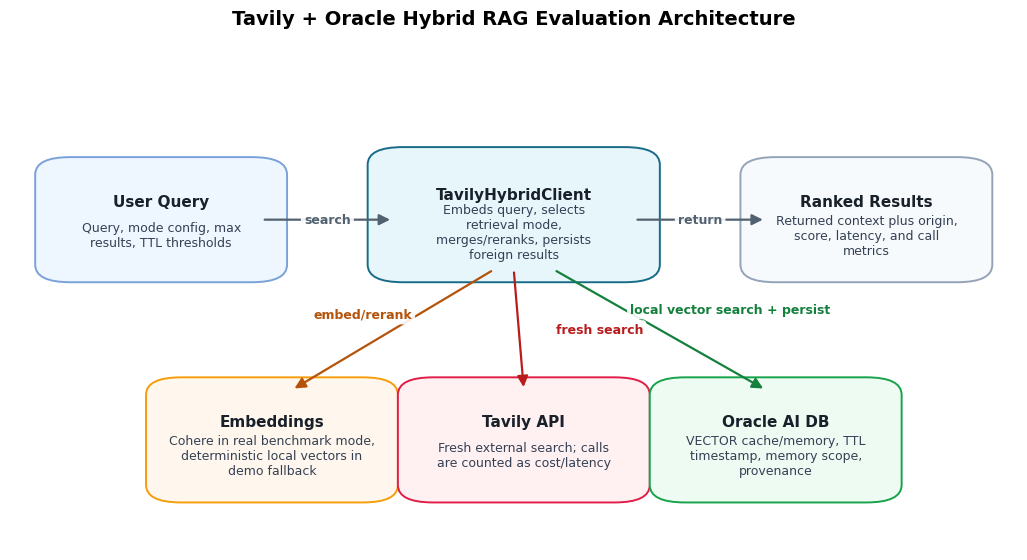

In [23]:
metrics_fig = plot_metrics_system_architecture()
if metrics_fig is not None:
    metrics_plt.show()


### Retrieval Mode Decision Flows

The three modes optimize for different product goals. These cards explain the behavior in review-friendly language.


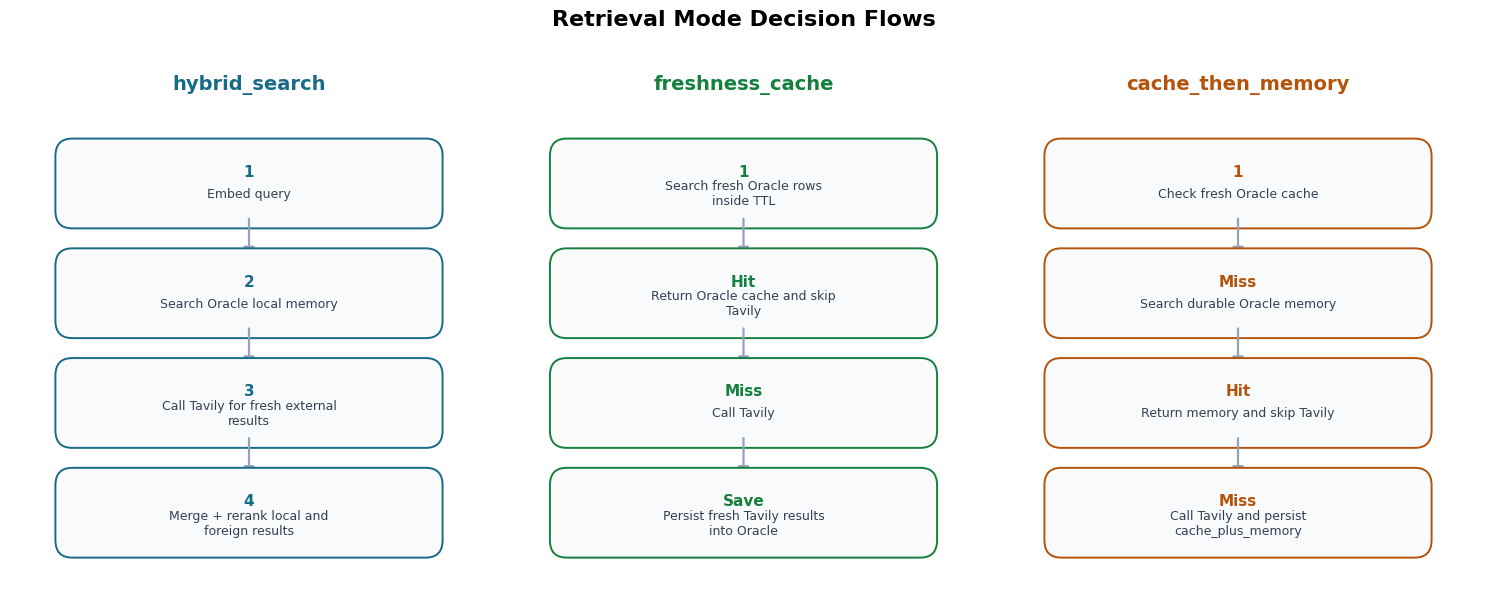

In [24]:
metrics_fig = plot_metrics_retrieval_flows()
if metrics_fig is not None:
    metrics_plt.show()


In [25]:
def metrics_find_repo_root(start: Path | None = None) -> Path:
    start = Path.cwd().resolve() if start is None else Path(start).resolve()
    for candidate in (start, *start.parents):
        if (candidate / "setup.py").exists() and (candidate / "tavily").is_dir():
            return candidate
    raise RuntimeError("Could not find tavily-python repo root from current working directory.")


def metrics_load_root_env(repo_root: Path) -> Path | None:
    env_path = repo_root / ".env"
    if not env_path.exists():
        return None

    proxy_keys = {"HTTP_PROXY", "HTTPS_PROXY", "ALL_PROXY", "NO_PROXY"}
    proxy_opt_in = metrics_truthy(os.getenv("TAVILY_LOAD_PROXY_ENV")) or metrics_truthy(os.getenv("ORACLE_LOAD_PROXY_ENV"))

    for raw_line in env_path.read_text(encoding="utf-8").splitlines():
        line = raw_line.strip()
        if not line or line.startswith("#") or "=" not in line:
            continue
        if line.startswith("export "):
            line = line[len("export "):].strip()
        key, value = line.split("=", 1)
        key = key.strip()
        value = value.strip().strip('"').strip("'")
        if not key or not value:
            continue
        if key.upper() in proxy_keys and not proxy_opt_in:
            continue
        os.environ.setdefault(key, value)
    return env_path


METRICS_REPO_ROOT = metrics_find_repo_root()
if str(METRICS_REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(METRICS_REPO_ROOT))

METRICS_ENV_PATH = metrics_load_root_env(METRICS_REPO_ROOT)
print("Metrics repo root:", METRICS_REPO_ROOT)
print("Metrics loaded .env:", bool(METRICS_ENV_PATH))
print("Metrics standard proxy env disabled via isolated requests session:", METRICS_DISABLE_PROXY)


Metrics repo root: /Users/anishraj/Desktop/Projects/Pod4_demo/tavily-python
Metrics loaded .env: True
Metrics standard proxy env disabled via isolated requests session: True


In [26]:
from tavily import TavilyHybridClient as MetricsTavilyHybridClient

METRICS_REQUIRED_REAL_ENV = [
    "TAVILY_API_KEY",
    "CO_API_KEY",
    "ORACLE_USER",
    "ORACLE_PASSWORD",
    "ORACLE_DSN",
]
METRICS_MISSING_REAL_ENV = [key for key in METRICS_REQUIRED_REAL_ENV if not os.getenv(key)]
METRICS_CAN_USE_REAL_ORACLE = (
    not METRICS_MISSING_REAL_ENV
    and not globals().get("ORACLE_DEMO_FALLBACK", False)
)
METRICS_CAN_USE_DEMO_FALLBACK = (
    METRICS_ALLOW_DEMO_FALLBACK
    and "DemoOracleConnection" in globals()
    and "DemoTavilyOracleClient" in globals()
    and "demo_embedding_function" in globals()
    and "score_ranking_function" in globals()
)

print("Metrics real env check:")
for key in METRICS_REQUIRED_REAL_ENV:
    print(f"  {key}: {'present' if os.getenv(key) else 'missing'}")
print("Metrics can use real Oracle benchmark:", METRICS_CAN_USE_REAL_ORACLE)
print("Metrics can use demo fallback benchmark:", METRICS_CAN_USE_DEMO_FALLBACK)


Metrics real env check:
  TAVILY_API_KEY: present
  CO_API_KEY: present
  ORACLE_USER: present
  ORACLE_PASSWORD: present
  ORACLE_DSN: present
Metrics can use real Oracle benchmark: True
Metrics can use demo fallback benchmark: True


In [27]:
METRICS_DEFAULT_TABLE = "TAVILY_METRICS_EVAL"
METRICS_TABLE_NAME = os.getenv("ORACLE_METRICS_TABLE", METRICS_DEFAULT_TABLE).upper()
METRICS_CONTENT_FIELD = os.getenv("ORACLE_CONTENT_FIELD", "CONTENT").upper()
METRICS_EMBEDDINGS_FIELD = os.getenv("ORACLE_EMBEDDINGS_FIELD", "EMBEDDINGS").upper()
METRICS_CACHE_TIMESTAMP_FIELD = os.getenv("ORACLE_CACHE_TIMESTAMP_FIELD", "ADDED_AT").upper()

METRICS_RESET_TABLE = metrics_truthy(os.getenv("RESET_METRICS_TABLE", "1"))
METRICS_ALLOW_RESET_CUSTOM_TABLE = metrics_truthy(os.getenv("ALLOW_RESET_CUSTOM_METRICS_TABLE", "0"))
METRICS_USE_REAL_TAVILY = metrics_truthy(os.getenv("METRICS_USE_REAL_TAVILY", "0"))

if METRICS_RESET_TABLE and METRICS_TABLE_NAME != METRICS_DEFAULT_TABLE and not METRICS_ALLOW_RESET_CUSTOM_TABLE:
    raise RuntimeError(
        "Refusing to reset a custom metrics table. Set ALLOW_RESET_CUSTOM_METRICS_TABLE=1 "
        "or use the default TAVILY_METRICS_EVAL table."
    )

METRICS_EVAL_QUERY = os.getenv(
    "METRICS_EVAL_QUERY",
    "latest Oracle vector search features for retrieval augmented generation",
)
METRICS_MAX_RESULTS = int(os.getenv("METRICS_MAX_RESULTS", "3"))
METRICS_MAX_LOCAL = int(os.getenv("METRICS_MAX_LOCAL", "3"))
METRICS_MAX_FOREIGN = int(os.getenv("METRICS_MAX_FOREIGN", "3"))

# Thresholds are intentionally permissive for this cache mechanics benchmark.
# Final relevance evaluation should use labeled examples and stricter acceptance criteria.
METRICS_CACHE_SCORE_THRESHOLD = float(os.getenv("METRICS_CACHE_SCORE_THRESHOLD", "-1.0"))
METRICS_MEMORY_SCORE_THRESHOLD = float(os.getenv("METRICS_MEMORY_SCORE_THRESHOLD", "-1.0"))
METRICS_FRESHNESS_TTL_SECONDS = int(os.getenv("METRICS_FRESHNESS_TTL_SECONDS", "3600"))
METRICS_MEMORY_TTL_SECONDS = int(os.getenv("METRICS_MEMORY_TTL_SECONDS", "1"))
METRICS_MEMORY_EXPIRY_SLEEP_SECONDS = float(os.getenv("METRICS_MEMORY_EXPIRY_SLEEP_SECONDS", "2"))

METRICS_TAVILY_SEARCH_OPTIONS = {
    "search_depth": os.getenv("METRICS_TAVILY_SEARCH_DEPTH", "basic"),
    "topic": os.getenv("METRICS_TAVILY_TOPIC", "general"),
    "include_answer": False,
    "include_raw_content": False,
}

metrics_benchmark_config = {
    "table_name": METRICS_TABLE_NAME,
    "content_field": METRICS_CONTENT_FIELD,
    "embeddings_field": METRICS_EMBEDDINGS_FIELD,
    "cache_timestamp_field": METRICS_CACHE_TIMESTAMP_FIELD,
    "reset_metrics_table": METRICS_RESET_TABLE,
    "use_real_tavily": METRICS_USE_REAL_TAVILY,
    "query": METRICS_EVAL_QUERY,
    "max_results": METRICS_MAX_RESULTS,
    "max_local": METRICS_MAX_LOCAL,
    "max_foreign": METRICS_MAX_FOREIGN,
    "cache_score_threshold": METRICS_CACHE_SCORE_THRESHOLD,
    "memory_score_threshold": METRICS_MEMORY_SCORE_THRESHOLD,
    "freshness_ttl_seconds": METRICS_FRESHNESS_TTL_SECONDS,
    "memory_ttl_seconds": METRICS_MEMORY_TTL_SECONDS,
    "memory_expiry_sleep_seconds": METRICS_MEMORY_EXPIRY_SLEEP_SECONDS,
    "tavily_search_options": METRICS_TAVILY_SEARCH_OPTIONS,
    "run_benchmark": METRICS_RUN_BENCHMARK,
}

print(json.dumps(metrics_benchmark_config, indent=2))


{
  "table_name": "TAVILY_METRICS_EVAL",
  "content_field": "CONTENT",
  "embeddings_field": "EMBEDDINGS",
  "cache_timestamp_field": "ADDED_AT",
  "reset_metrics_table": true,
  "use_real_tavily": false,
  "query": "latest Oracle vector search features for retrieval augmented generation",
  "max_results": 3,
  "max_local": 3,
  "max_foreign": 3,
  "cache_score_threshold": -1.0,
  "memory_score_threshold": -1.0,
  "freshness_ttl_seconds": 3600,
  "memory_ttl_seconds": 1,
  "memory_expiry_sleep_seconds": 2.0,
  "tavily_search_options": {
    "search_depth": "basic",
    "topic": "general",
    "include_answer": false,
    "include_raw_content": false
  },
  "run_benchmark": true
}


### Connect To Oracle And Prepare Metrics Table

The real benchmark uses a dedicated metrics table with `VECTOR(*, FLOAT32)` so the SDK can persist Cohere embeddings without colliding with the deterministic demo rows above. In demo fallback mode, the benchmark uses an isolated in-memory Oracle-shaped connection.


In [28]:
def metrics_table_columns_for_demo() -> list[dict]:
    return [
        {"column": "ID", "type": "NUMBER", "length": None, "nullable": "N"},
        {"column": METRICS_CONTENT_FIELD, "type": "CLOB", "length": None, "nullable": "Y"},
        {"column": METRICS_EMBEDDINGS_FIELD, "type": "VECTOR", "length": None, "nullable": "Y"},
        {"column": METRICS_CACHE_TIMESTAMP_FIELD, "type": "TIMESTAMP", "length": None, "nullable": "Y"},
        {"column": "RAW_PAYLOAD", "type": "JSON", "length": None, "nullable": "Y"},
        {"column": "SOURCE_URL", "type": "VARCHAR2", "length": 1000, "nullable": "Y"},
        {"column": "SOURCE_TITLE", "type": "VARCHAR2", "length": 1000, "nullable": "Y"},
        {"column": "RETRIEVAL_QUERY", "type": "VARCHAR2", "length": 1000, "nullable": "Y"},
        {"column": "RETRIEVAL_TIMESTAMP", "type": "TIMESTAMP", "length": None, "nullable": "Y"},
        {"column": "RETRIEVAL_MODE", "type": "VARCHAR2", "length": 30, "nullable": "Y"},
        {"column": "CACHE_HIT", "type": "NUMBER", "length": None, "nullable": "Y"},
        {"column": "INSERTED_FROM", "type": "VARCHAR2", "length": 30, "nullable": "Y"},
        {"column": "PROVIDER_NAME", "type": "VARCHAR2", "length": 50, "nullable": "Y"},
        {"column": "MEMORY_SCOPE", "type": "VARCHAR2", "length": 30, "nullable": "Y"},
        {"column": "EXPIRES_AT", "type": "TIMESTAMP", "length": None, "nullable": "Y"},
        {"column": "LAST_SEEN_AT", "type": "TIMESTAMP", "length": None, "nullable": "Y"},
        {"column": "QUERY_COUNT", "type": "NUMBER", "length": None, "nullable": "Y"},
        {"column": "CONTENT_HASH", "type": "VARCHAR2", "length": 64, "nullable": "Y"},
    ]


def metrics_table_exists(metrics_connection, table_name: str) -> bool:
    if isinstance(metrics_connection, globals().get("DemoOracleConnection", ())):
        return True
    with metrics_connection.cursor() as cursor:
        cursor.execute(
            "SELECT COUNT(*) FROM USER_TABLES WHERE TABLE_NAME = :table_name",
            table_name=table_name.upper(),
        )
        return cursor.fetchone()[0] > 0


def metrics_drop_table_if_exists(metrics_connection, table_name: str) -> None:
    if not metrics_table_exists(metrics_connection, table_name):
        return
    with metrics_connection.cursor() as cursor:
        cursor.execute(f"DROP TABLE {table_name} PURGE")
    metrics_connection.commit()


def metrics_create_table_if_needed(metrics_connection, table_name: str) -> None:
    if metrics_table_exists(metrics_connection, table_name):
        return
    ddl = f"""
        CREATE TABLE {table_name} (
            ID NUMBER GENERATED BY DEFAULT AS IDENTITY PRIMARY KEY,
            {METRICS_CONTENT_FIELD} CLOB NOT NULL,
            {METRICS_EMBEDDINGS_FIELD} VECTOR(*, FLOAT32) NOT NULL,
            {METRICS_CACHE_TIMESTAMP_FIELD} TIMESTAMP DEFAULT SYSTIMESTAMP,
            RAW_PAYLOAD CLOB,
            SOURCE_URL VARCHAR2(1000),
            SOURCE_TITLE VARCHAR2(1000),
            RETRIEVAL_QUERY VARCHAR2(1000),
            RETRIEVAL_TIMESTAMP TIMESTAMP,
            RETRIEVAL_MODE VARCHAR2(30),
            CACHE_HIT NUMBER(1),
            INSERTED_FROM VARCHAR2(30),
            PROVIDER_NAME VARCHAR2(50),
            MEMORY_SCOPE VARCHAR2(30),
            EXPIRES_AT TIMESTAMP,
            LAST_SEEN_AT TIMESTAMP,
            QUERY_COUNT NUMBER,
            CONTENT_HASH VARCHAR2(64)
        )
    """
    with metrics_connection.cursor() as cursor:
        cursor.execute(ddl)
    metrics_connection.commit()


def metrics_table_columns(metrics_connection, table_name: str) -> list[dict]:
    if isinstance(metrics_connection, globals().get("DemoOracleConnection", ())):
        return metrics_table_columns_for_demo()
    with metrics_connection.cursor() as cursor:
        cursor.execute(
            """
            SELECT COLUMN_NAME, DATA_TYPE, DATA_LENGTH, NULLABLE
            FROM USER_TAB_COLUMNS
            WHERE TABLE_NAME = :table_name
            ORDER BY COLUMN_ID
            """,
            table_name=table_name.upper(),
        )
        return [
            {"column": row[0], "type": row[1], "length": row[2], "nullable": row[3]}
            for row in cursor.fetchall()
        ]


metrics_connection = None
metrics_oracle_schema = None
METRICS_USE_DEMO_FALLBACK = False
METRICS_BENCHMARK_READY = False

if not METRICS_RUN_BENCHMARK:
    print("Metrics benchmark skipped. Set RUN_ORACLE_METRICS_EVAL=1 to run it.")
elif METRICS_CAN_USE_REAL_ORACLE:
    metrics_connection = oracledb.connect(
        user=os.environ["ORACLE_USER"],
        password=os.environ["ORACLE_PASSWORD"],
        dsn=os.environ["ORACLE_DSN"],
    )
    with metrics_connection.cursor() as cursor:
        cursor.execute("SELECT USER FROM DUAL")
        metrics_oracle_schema = cursor.fetchone()[0]
    if METRICS_RESET_TABLE:
        metrics_drop_table_if_exists(metrics_connection, METRICS_TABLE_NAME)
    metrics_create_table_if_needed(metrics_connection, METRICS_TABLE_NAME)
    METRICS_BENCHMARK_READY = True
    print("Metrics Oracle connection: OK")
    print("Metrics Oracle schema:", metrics_oracle_schema)
elif METRICS_CAN_USE_DEMO_FALLBACK:
    metrics_connection = DemoOracleConnection(METRICS_TABLE_NAME)
    metrics_oracle_schema = metrics_connection.current_schema
    METRICS_USE_DEMO_FALLBACK = True
    METRICS_BENCHMARK_READY = True
    print("Metrics benchmark will use in-memory demo fallback.")
    print("Metrics fallback schema:", metrics_oracle_schema)
else:
    print("Metrics benchmark requested but prerequisites are incomplete.")
    print("Missing real benchmark env vars:", ", ".join(METRICS_MISSING_REAL_ENV) or "none")
    print("Demo fallback available:", METRICS_CAN_USE_DEMO_FALLBACK)

if METRICS_BENCHMARK_READY:
    print("Metrics table:", METRICS_TABLE_NAME)
    print("Reset table before benchmark:", METRICS_RESET_TABLE and not METRICS_USE_DEMO_FALLBACK)


Metrics Oracle connection: OK
Metrics Oracle schema: TAVILY_ITEST
Metrics table: TAVILY_METRICS_EVAL
Reset table before benchmark: True


In [29]:
def metrics_markdown_table(rows: list[dict], columns: list[str] | None = None) -> str:
    if not rows:
        return "_No rows._"
    columns = columns or list(rows[0].keys())

    def fmt(value):
        if value is None:
            return ""
        if isinstance(value, float):
            return f"{value:.3f}"
        text = str(value).replace("|", "\\|").replace("\n", " ")
        return text

    header = "| " + " | ".join(columns) + " |"
    divider = "| " + " | ".join(["---"] * len(columns)) + " |"
    body = ["| " + " | ".join(fmt(row.get(col)) for col in columns) + " |" for row in rows]
    return "\n".join([header, divider, *body])


if METRICS_BENCHMARK_READY:
    metrics_display_markdown(metrics_markdown_table(metrics_table_columns(metrics_connection, METRICS_TABLE_NAME)))
else:
    print("Metrics table inspection skipped.")


| column | type | length | nullable |
| --- | --- | --- | --- |
| ID | NUMBER | 22 | N |
| CONTENT | CLOB | 4000 | N |
| EMBEDDINGS | VECTOR | 8200 | N |
| ADDED_AT | TIMESTAMP(6) | 11 | Y |
| RAW_PAYLOAD | CLOB | 4000 | Y |
| SOURCE_URL | VARCHAR2 | 1000 | Y |
| SOURCE_TITLE | VARCHAR2 | 1000 | Y |
| RETRIEVAL_QUERY | VARCHAR2 | 1000 | Y |
| RETRIEVAL_TIMESTAMP | TIMESTAMP(6) | 11 | Y |
| RETRIEVAL_MODE | VARCHAR2 | 30 | Y |
| CACHE_HIT | NUMBER | 22 | Y |
| INSERTED_FROM | VARCHAR2 | 30 | Y |
| PROVIDER_NAME | VARCHAR2 | 50 | Y |
| MEMORY_SCOPE | VARCHAR2 | 30 | Y |
| EXPIRES_AT | TIMESTAMP(6) | 11 | Y |
| LAST_SEEN_AT | TIMESTAMP(6) | 11 | Y |
| QUERY_COUNT | NUMBER | 22 | Y |
| CONTENT_HASH | VARCHAR2 | 64 | Y |

### Instrumentation Helpers

These helpers do not fake the SDK in real benchmark mode. They wrap the Tavily client only to count calls and measure elapsed time. Demo fallback mode uses the notebook's in-memory fallback classes.


In [30]:
class MetricsTavilyCallCounter:
    def __init__(self, client):
        self.client = client
        self.calls = 0
        self.latencies_ms = []
        self._original_search = client.tavily.search

    def install(self):
        def wrapped_search(*args, **kwargs):
            start = time.perf_counter()
            self.calls += 1
            try:
                return self._original_search(*args, **kwargs)
            finally:
                self.latencies_ms.append((time.perf_counter() - start) * 1000)
        self.client.tavily.search = wrapped_search
        return self

    def delta_since(self, previous_calls: int) -> int:
        return self.calls - previous_calls


def metrics_sha256_text(text: str) -> str:
    return hashlib.sha256(str(text).encode("utf-8")).hexdigest()


def metrics_content_hashes(results: list[dict]) -> set[str]:
    return {metrics_sha256_text(row.get("content", "")) for row in results if row.get("content")}


def metrics_result_origin_counts(results: list[dict]) -> Counter:
    return Counter(row.get("origin", "unknown") for row in results)


def metrics_table_row_count(metrics_connection, table_name: str) -> int:
    if isinstance(metrics_connection, globals().get("DemoOracleConnection", ())):
        return len(metrics_connection.rows)
    with metrics_connection.cursor() as cursor:
        cursor.execute(f"SELECT COUNT(*) FROM {table_name}")
        return int(cursor.fetchone()[0])


def metrics_metadata_summary(metrics_connection, table_name: str) -> dict:
    keys = [
        "total_rows",
        "source_url_rows",
        "source_title_rows",
        "query_rows",
        "mode_rows",
        "inserted_from_rows",
        "provider_rows",
        "memory_scope_rows",
        "raw_payload_rows",
    ]
    if isinstance(metrics_connection, globals().get("DemoOracleConnection", ())):
        rows = metrics_connection.rows
        summary = {
            "total_rows": len(rows),
            "source_url_rows": sum(1 for row in rows if row.get("SOURCE_URL") is not None),
            "source_title_rows": sum(1 for row in rows if row.get("SOURCE_TITLE") is not None),
            "query_rows": sum(1 for row in rows if row.get("RETRIEVAL_QUERY") is not None),
            "mode_rows": sum(1 for row in rows if row.get("RETRIEVAL_MODE") is not None),
            "inserted_from_rows": sum(1 for row in rows if row.get("INSERTED_FROM") is not None),
            "provider_rows": sum(1 for row in rows if row.get("PROVIDER_NAME") is not None),
            "memory_scope_rows": sum(1 for row in rows if row.get("MEMORY_SCOPE") is not None),
            "raw_payload_rows": sum(1 for row in rows if row.get("RAW_PAYLOAD") is not None),
        }
    else:
        with metrics_connection.cursor() as cursor:
            cursor.execute(
                f"""
                SELECT COUNT(*) AS total_rows,
                       SUM(CASE WHEN SOURCE_URL IS NOT NULL THEN 1 ELSE 0 END) AS source_url_rows,
                       SUM(CASE WHEN SOURCE_TITLE IS NOT NULL THEN 1 ELSE 0 END) AS source_title_rows,
                       SUM(CASE WHEN RETRIEVAL_QUERY IS NOT NULL THEN 1 ELSE 0 END) AS query_rows,
                       SUM(CASE WHEN RETRIEVAL_MODE IS NOT NULL THEN 1 ELSE 0 END) AS mode_rows,
                       SUM(CASE WHEN INSERTED_FROM IS NOT NULL THEN 1 ELSE 0 END) AS inserted_from_rows,
                       SUM(CASE WHEN PROVIDER_NAME IS NOT NULL THEN 1 ELSE 0 END) AS provider_rows,
                       SUM(CASE WHEN MEMORY_SCOPE IS NOT NULL THEN 1 ELSE 0 END) AS memory_scope_rows,
                       SUM(CASE WHEN RAW_PAYLOAD IS NOT NULL THEN 1 ELSE 0 END) AS raw_payload_rows
                FROM {table_name}
                """
            )
            row = cursor.fetchone()
        summary = dict(zip(keys, [int(value or 0) for value in row]))

    filled = sum(summary[key] for key in keys[1:])
    possible = summary["total_rows"] * (len(keys) - 1)
    summary["metadata_completeness_pct"] = (filled / possible * 100) if possible else None
    return summary


def metrics_memory_scope_counts(metrics_connection, table_name: str) -> list[dict]:
    if isinstance(metrics_connection, globals().get("DemoOracleConnection", ())):
        counts = Counter(
            (
                row.get("MEMORY_SCOPE") or "(none)",
                row.get("RETRIEVAL_MODE") or "(none)",
            )
            for row in metrics_connection.rows
        )
        return [
            {"memory_scope": scope, "retrieval_mode": mode, "rows_count": count}
            for (scope, mode), count in sorted(counts.items())
        ]

    with metrics_connection.cursor() as cursor:
        cursor.execute(
            f"""
            SELECT NVL(MEMORY_SCOPE, '(none)') AS memory_scope,
                   NVL(RETRIEVAL_MODE, '(none)') AS retrieval_mode,
                   COUNT(*) AS rows_count
            FROM {table_name}
            GROUP BY NVL(MEMORY_SCOPE, '(none)'), NVL(RETRIEVAL_MODE, '(none)')
            ORDER BY memory_scope, retrieval_mode
            """
        )
        return [
            {"memory_scope": row[0], "retrieval_mode": row[1], "rows_count": int(row[2])}
            for row in cursor.fetchall()
        ]


def metrics_reset_rows(metrics_connection, table_name: str) -> None:
    if isinstance(metrics_connection, globals().get("DemoOracleConnection", ())):
        metrics_connection.rows.clear()
        metrics_connection._next_id = 1
        return
    with metrics_connection.cursor() as cursor:
        cursor.execute(f"TRUNCATE TABLE {table_name}")
    metrics_connection.commit()


def metrics_result_preview(results: list[dict], chars: int = 120) -> list[dict]:
    preview = []
    for idx, row in enumerate(results, 1):
        text = str(row.get("content", ""))
        preview.append({
            "rank": idx,
            "origin": row.get("origin"),
            "score": float(row.get("score", 0) or 0),
            "content": text[:chars] + ("..." if len(text) > chars else ""),
        })
    return preview


In [31]:
def metrics_demo_tavily_search(query, max_results=5, **_kwargs):
    return {"results": demo_foreign_results(query, max_results)}


def metrics_make_oracle_client(retrieval_mode: str, *, cache_ttl_seconds: int, persistence_depth: str):
    metrics_session = None
    if metrics_requests is not None and METRICS_DISABLE_PROXY:
        metrics_session = metrics_requests.Session()
        metrics_session.trust_env = False

    if METRICS_USE_DEMO_FALLBACK:
        client = DemoTavilyOracleClient(
            api_key=os.environ["TAVILY_API_KEY"],
            connection=metrics_connection,
            table_name=METRICS_TABLE_NAME,
            content_field=METRICS_CONTENT_FIELD,
            embeddings_field=METRICS_EMBEDDINGS_FIELD,
            cache_timestamp_field=METRICS_CACHE_TIMESTAMP_FIELD,
            embedding_function=demo_embedding_function,
            ranking_function=score_ranking_function,
            retrieval_mode=retrieval_mode,
            cache_ttl_seconds=cache_ttl_seconds,
            cache_score_threshold=METRICS_CACHE_SCORE_THRESHOLD,
            memory_score_threshold=METRICS_MEMORY_SCORE_THRESHOLD,
            memory_max_results=METRICS_MAX_LOCAL,
            persistence_depth=persistence_depth,
            enable_oracle_memory_metadata=True,
            enable_oracle_json_payload=True,
            enable_provenance_metadata=True,
            oracle_upsert_key="content_hash",
            max_persisted_foreign=METRICS_MAX_FOREIGN,
            session=metrics_session,
        )
    else:
        client = MetricsTavilyHybridClient(
            api_key=os.environ["TAVILY_API_KEY"],
            db_provider="oracle",
            connection=metrics_connection,
            table_name=METRICS_TABLE_NAME,
            content_field=METRICS_CONTENT_FIELD,
            embeddings_field=METRICS_EMBEDDINGS_FIELD,
            retrieval_mode=retrieval_mode,
            cache_timestamp_field=METRICS_CACHE_TIMESTAMP_FIELD,
            cache_ttl_seconds=cache_ttl_seconds,
            cache_score_threshold=METRICS_CACHE_SCORE_THRESHOLD,
            memory_score_threshold=METRICS_MEMORY_SCORE_THRESHOLD,
            memory_max_results=METRICS_MAX_LOCAL,
            persistence_depth=persistence_depth,
            enable_oracle_memory_metadata=True,
            enable_oracle_json_payload=True,
            enable_provenance_metadata=True,
            oracle_upsert_key="content_hash",
            max_persisted_foreign=METRICS_MAX_FOREIGN,
            session=metrics_session,
        )
    if not METRICS_USE_REAL_TAVILY:
        client.tavily.search = metrics_demo_tavily_search

    counter = MetricsTavilyCallCounter(client).install()
    return client, counter


def metrics_run_scenario(
    *,
    mode: str,
    runs: int,
    cache_ttl_seconds: int,
    persistence_depth: str,
    sleep_before_run: dict[int, float] | None = None,
) -> dict:
    sleep_before_run = sleep_before_run or {}
    metrics_reset_rows(metrics_connection, METRICS_TABLE_NAME)

    client, counter = metrics_make_oracle_client(
        mode,
        cache_ttl_seconds=cache_ttl_seconds,
        persistence_depth=persistence_depth,
    )

    rows = []
    reference_hashes: set[str] | None = None
    scenario_start = time.perf_counter()

    try:
        for run_number in range(1, runs + 1):
            sleep_seconds = sleep_before_run.get(run_number, 0)
            if sleep_seconds:
                time.sleep(sleep_seconds)

            row_count_before = metrics_table_row_count(metrics_connection, METRICS_TABLE_NAME)
            calls_before = counter.calls
            start = time.perf_counter()
            results = client.search(
                query=METRICS_EVAL_QUERY,
                max_results=METRICS_MAX_RESULTS,
                max_local=METRICS_MAX_LOCAL,
                max_foreign=METRICS_MAX_FOREIGN,
                save_foreign=True,
                **METRICS_TAVILY_SEARCH_OPTIONS,
            )
            elapsed_ms = (time.perf_counter() - start) * 1000
            tavily_calls = counter.delta_since(calls_before)
            row_count_after = metrics_table_row_count(metrics_connection, METRICS_TABLE_NAME)
            origins = metrics_result_origin_counts(results)
            hashes = metrics_content_hashes(results)

            if tavily_calls > 0 and origins.get("foreign", 0) > 0 and reference_hashes is None:
                reference_hashes = hashes

            replay_overlap_pct = None
            if reference_hashes:
                replay_overlap_pct = len(hashes & reference_hashes) / len(reference_hashes) * 100

            rows.append({
                "mode": mode,
                "run": run_number,
                "latency_ms": elapsed_ms,
                "tavily_calls": tavily_calls,
                "avoided_tavily_calls": max(0, 1 - tavily_calls),
                "cache_hit_inferred": tavily_calls == 0 and origins.get("local", 0) > 0,
                "local_results": origins.get("local", 0),
                "foreign_results": origins.get("foreign", 0),
                "total_results": len(results),
                "rows_before": row_count_before,
                "rows_after": row_count_after,
                "rows_delta": row_count_after - row_count_before,
                "replay_overlap_pct": replay_overlap_pct,
                "sleep_before_seconds": sleep_seconds,
                "result_preview": metrics_result_preview(results),
            })
    finally:
        with suppress(Exception):
            client.close()

    total_runtime_ms = (time.perf_counter() - scenario_start) * 1000
    persisted_metadata = metrics_metadata_summary(metrics_connection, METRICS_TABLE_NAME)
    scopes = metrics_memory_scope_counts(metrics_connection, METRICS_TABLE_NAME)

    return {
        "mode": mode,
        "runs": rows,
        "total_runtime_ms": total_runtime_ms,
        "tavily_call_latencies_ms": counter.latencies_ms,
        "persisted_metadata": persisted_metadata,
        "memory_scope_counts": scopes,
    }


### Run The Benchmark

Expected behavior:

- `hybrid_search`: calls Tavily every run when `max_foreign > 0`; after the first run, it also has Oracle local memory available.
- `freshness_cache`: first run should call Tavily and persist rows; second run should be served from Oracle cache and avoid Tavily.
- `cache_then_memory`: first run should call Tavily and persist durable memory rows; after TTL expiry, second run should miss the fresh-cache tier, hit the memory tier, and avoid Tavily.


In [32]:
metrics_benchmark_started_at = None
metrics_benchmark_finished_at = None
metrics_scenarios = []

if not METRICS_RUN_BENCHMARK:
    print("Metrics benchmark not run. Set RUN_ORACLE_METRICS_EVAL=1, or leave it unset for this demo notebook, to execute it.")
elif not METRICS_BENCHMARK_READY:
    raise RuntimeError(
        "Metrics benchmark was requested, but no real Oracle connection or demo fallback is ready. "
        "Check CO_API_KEY, ORACLE_* env vars, or ORACLE_METRICS_ALLOW_DEMO_FALLBACK."
    )
else:
    metrics_benchmark_started_at = datetime.now(timezone.utc).isoformat()

    metrics_scenarios = [
        metrics_run_scenario(
            mode="hybrid_search",
            runs=2,
            cache_ttl_seconds=METRICS_FRESHNESS_TTL_SECONDS,
            persistence_depth="cache_plus_memory",
        ),
        metrics_run_scenario(
            mode="freshness_cache",
            runs=2,
            cache_ttl_seconds=METRICS_FRESHNESS_TTL_SECONDS,
            persistence_depth="cache_only",
        ),
        metrics_run_scenario(
            mode="cache_then_memory",
            runs=2,
            cache_ttl_seconds=METRICS_MEMORY_TTL_SECONDS,
            persistence_depth="cache_plus_memory",
            sleep_before_run={2: METRICS_MEMORY_EXPIRY_SLEEP_SECONDS},
        ),
    ]

    metrics_benchmark_finished_at = datetime.now(timezone.utc).isoformat()
    print("Metrics benchmark started:", metrics_benchmark_started_at)
    print("Metrics benchmark finished:", metrics_benchmark_finished_at)


Metrics benchmark started: 2026-06-04T15:39:47.389906+00:00
Metrics benchmark finished: 2026-06-04T15:39:56.571349+00:00


### Per-Run Metrics

Each row below is a measured call to `TavilyHybridClient.search(...)` in real mode or the notebook's demo fallback client in fallback mode.


In [33]:
metrics_per_run_rows = []
for metrics_scenario in metrics_scenarios:
    for row in metrics_scenario["runs"]:
        metrics_per_run_rows.append({
            "mode": row["mode"],
            "run": row["run"],
            "latency_ms": row["latency_ms"],
            "tavily_calls": row["tavily_calls"],
            "avoided_calls": row["avoided_tavily_calls"],
            "cache_hit": row["cache_hit_inferred"],
            "local": row["local_results"],
            "foreign": row["foreign_results"],
            "rows_delta": row["rows_delta"],
            "replay_overlap_pct": row["replay_overlap_pct"],
            "sleep_before_s": row["sleep_before_seconds"],
        })

metrics_display_markdown(metrics_markdown_table(metrics_per_run_rows))


| mode | run | latency_ms | tavily_calls | avoided_calls | cache_hit | local | foreign | rows_delta | replay_overlap_pct | sleep_before_s |
| --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- |
| hybrid_search | 1 | 2633.098 | 1 | 0 | False | 0 | 3 | 3 | 100.000 | 0 |
| hybrid_search | 2 | 2102.812 | 1 | 0 | False | 2 | 1 | 0 | 66.667 | 0 |
| freshness_cache | 1 | 757.860 | 1 | 0 | False | 0 | 3 | 3 | 100.000 | 0 |
| freshness_cache | 2 | 380.136 | 0 | 1 | True | 3 | 0 | 0 | 100.000 | 0 |
| cache_then_memory | 1 | 765.259 | 1 | 0 | False | 0 | 3 | 3 | 100.000 | 0 |
| cache_then_memory | 2 | 366.029 | 0 | 1 | True | 3 | 0 | 0 | 100.000 | 2.000 |

### Mode-Level Summary

`avoided_tavily_calls` is measured against a simple baseline: one Tavily call per search run when `max_foreign > 0`.


In [34]:
def metrics_mean(values: list[float]) -> float | None:
    return statistics.mean(values) if values else None


def metrics_percentile(values: list[float], pct: float) -> float | None:
    if not values:
        return None
    ordered = sorted(values)
    idx = round((len(ordered) - 1) * pct)
    return ordered[idx]


metrics_summary_rows = []
for metrics_scenario in metrics_scenarios:
    runs = metrics_scenario["runs"]
    latencies = [row["latency_ms"] for row in runs]
    overlaps = [row["replay_overlap_pct"] for row in runs if row["replay_overlap_pct"] is not None]
    total_calls = sum(row["tavily_calls"] for row in runs)
    avoided_calls = sum(row["avoided_tavily_calls"] for row in runs)
    cache_hits = sum(1 for row in runs if row["cache_hit_inferred"])
    metrics_summary_rows.append({
        "mode": metrics_scenario["mode"],
        "runs": len(runs),
        "avg_latency_ms": metrics_mean(latencies),
        "p95_latency_ms": metrics_percentile(latencies, 0.95),
        "total_runtime_ms": metrics_scenario["total_runtime_ms"],
        "tavily_calls": total_calls,
        "avoided_tavily_calls": avoided_calls,
        "cache_hit_rate_pct": cache_hits / len(runs) * 100,
        "avg_replay_overlap_pct": metrics_mean(overlaps),
        "persisted_rows": metrics_scenario["persisted_metadata"]["total_rows"],
        "metadata_completeness_pct": metrics_scenario["persisted_metadata"]["metadata_completeness_pct"],
    })

metrics_display_markdown(metrics_markdown_table(metrics_summary_rows))


| mode | runs | avg_latency_ms | p95_latency_ms | total_runtime_ms | tavily_calls | avoided_tavily_calls | cache_hit_rate_pct | avg_replay_overlap_pct | persisted_rows | metadata_completeness_pct |
| --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- |
| hybrid_search | 2 | 2367.955 | 2633.098 | 4743.221 | 2 | 0 | 0.000 | 83.333 | 3 | 100.000 |
| freshness_cache | 2 | 568.998 | 757.860 | 1144.549 | 1 | 1 | 50.000 | 100.000 | 3 | 100.000 |
| cache_then_memory | 2 | 565.644 | 765.259 | 3144.969 | 1 | 1 | 50.000 | 100.000 | 3 | 100.000 |

### Executive Dashboard

This dashboard is generated from the benchmark run above. It is the high-level view for mentors/managers: latency, avoided external calls, cache hit behavior, and persistence quality.


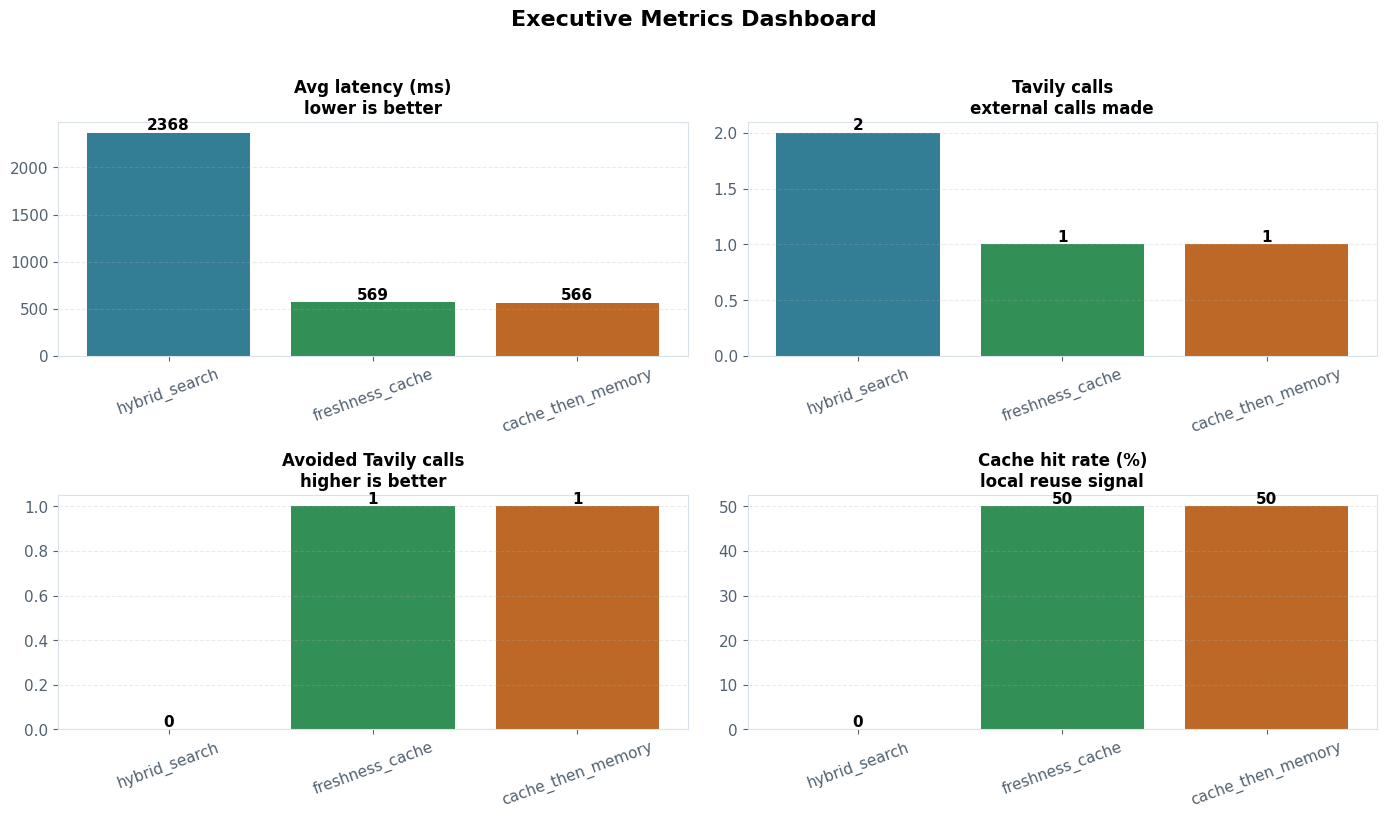

In [35]:
if metrics_summary_rows:
    metrics_fig = plot_metrics_executive_dashboard(metrics_summary_rows)
    if metrics_fig is not None:
        metrics_plt.show()
else:
    print("Metrics dashboard skipped because no benchmark rows are available.")


### Visual Comparison Charts

These charts use measured `metrics_summary_rows`, not hand-entered numbers.


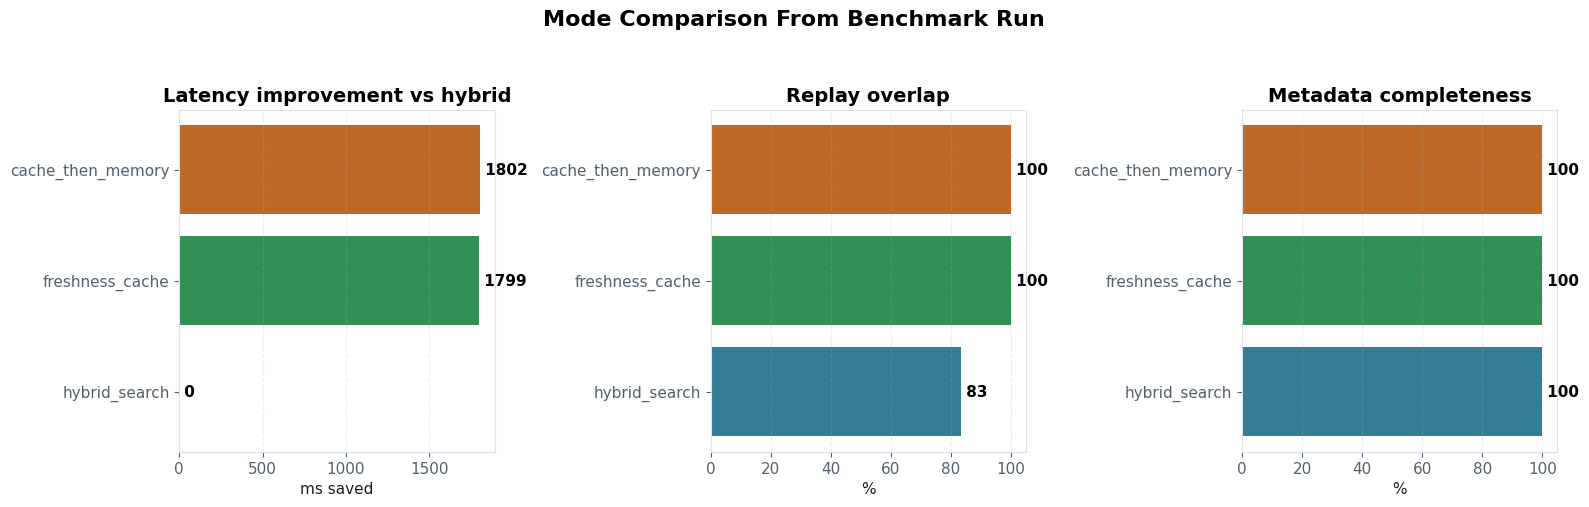

In [36]:
if metrics_summary_rows:
    metrics_fig = plot_metrics_comparison_charts(metrics_summary_rows)
    if metrics_fig is not None:
        metrics_plt.show()
else:
    print("Metrics comparison charts skipped because no benchmark rows are available.")


### Trade-Off Summary For Review

| Mode | What it optimizes | What to watch |
| --- | --- | --- |
| `hybrid_search` | Best freshness story because Tavily is called each run and merged with Oracle memory. | More external calls and higher repeat-query cost. |
| `freshness_cache` | Lowest repeat-query cost while cache TTL is valid. | Can return stale results if TTL is too long for the use case. |
| `cache_then_memory` | Best workflow recovery story because durable memory can still answer after cache expiry. | Needs careful memory governance so old-but-relevant context is separated from stale facts. |

Recommended final evaluation path:

1. Keep these operational metrics for every benchmark run.
2. Add a labeled golden query set and compute `recall@k`, `precision@k`, and `nDCG@k` for retrieval quality.
3. Add cost reporting once Tavily/Cohere usage accounting is available in the test environment.


### Persisted Metadata Completeness

This checks whether Tavily result provenance and Oracle memory metadata were written into the benchmark store. It is the part of the prompt closest to metadata faithfulness.


In [37]:
metrics_metadata_rows = []
for metrics_scenario in metrics_scenarios:
    metadata = metrics_scenario["persisted_metadata"]
    metrics_metadata_rows.append({"mode": metrics_scenario["mode"], **metadata})

metrics_display_markdown(metrics_markdown_table(metrics_metadata_rows))


| mode | total_rows | source_url_rows | source_title_rows | query_rows | mode_rows | inserted_from_rows | provider_rows | memory_scope_rows | raw_payload_rows | metadata_completeness_pct |
| --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- |
| hybrid_search | 3 | 3 | 3 | 3 | 3 | 3 | 3 | 3 | 3 | 100.000 |
| freshness_cache | 3 | 3 | 3 | 3 | 3 | 3 | 3 | 3 | 3 | 100.000 |
| cache_then_memory | 3 | 3 | 3 | 3 | 3 | 3 | 3 | 3 | 3 | 100.000 |

### Memory Scope Validation

For `cache_then_memory`, persisted rows should use `cache_plus_memory`. This is what allows a result to survive cache expiry and be returned by the durable memory tier.


In [38]:
metrics_scope_rows = []
for metrics_scenario in metrics_scenarios:
    for row in metrics_scenario["memory_scope_counts"]:
        metrics_scope_rows.append({"mode": metrics_scenario["mode"], **row})

metrics_display_markdown(metrics_markdown_table(metrics_scope_rows))


| mode | memory_scope | retrieval_mode | rows_count |
| --- | --- | --- | --- |
| hybrid_search | cache_plus_memory | hybrid_search | 3 |
| freshness_cache | cache_only | freshness_cache | 3 |
| cache_then_memory | cache_plus_memory | cache_then_memory | 3 |

### Result Previews

These snippets make the metrics auditable without exposing API keys or database credentials.


In [39]:
for metrics_scenario in metrics_scenarios:
    metrics_display_markdown(f"### {metrics_scenario['mode']}")
    for row in metrics_scenario["runs"]:
        metrics_display_markdown(f"**Run {row['run']}** - latency `{row['latency_ms']:.1f} ms`, Tavily calls `{row['tavily_calls']}`")
        metrics_display_markdown(metrics_markdown_table(row["result_preview"]))

if not metrics_scenarios:
    print("Metrics result previews skipped because no benchmark rows are available.")


### hybrid_search

**Run 1** - latency `2633.1 ms`, Tavily calls `1`

| rank | origin | score | content |
| --- | --- | --- | --- |
| 1 | foreign | 1.000 | Oracle Database 23ai includes AI Vector Search for semantic retrieval over enterprise data, with Tavily providing fresh ... |
| 2 | foreign | 0.998 | Oracle VECTOR columns can store embeddings beside JSON provenance, source URLs, retrieval modes, and timestamps for audi... |
| 3 | foreign | 0.997 | A freshness cache keeps recent Tavily search results close to the application while allowing cache misses to fetch curre... |

**Run 2** - latency `2102.8 ms`, Tavily calls `1`

| rank | origin | score | content |
| --- | --- | --- | --- |
| 1 | local | 1.000 | Oracle Database 23ai includes AI Vector Search for semantic retrieval over enterprise data, with Tavily providing fresh ... |
| 2 | foreign | 1.000 | Oracle Database 23ai includes AI Vector Search for semantic retrieval over enterprise data, with Tavily providing fresh ... |
| 3 | local | 0.998 | Oracle VECTOR columns can store embeddings beside JSON provenance, source URLs, retrieval modes, and timestamps for audi... |

...

### cache_then_memory

**Run 1** - latency `765.3 ms`, Tavily calls `1`

| rank | origin | score | content |
| --- | --- | --- | --- |
| 1 | foreign | 0.920 | Oracle Database 23ai includes AI Vector Search for semantic retrieval over enterprise data, with Tavily providing fresh ... |
| 2 | foreign | 0.880 | Oracle VECTOR columns can store embeddings beside JSON provenance, source URLs, retrieval modes, and timestamps for audi... |
| 3 | foreign | 0.840 | A freshness cache keeps recent Tavily search results close to the application while allowing cache misses to fetch curre... |

**Run 2** - latency `366.0 ms`, Tavily calls `0`

| rank | origin | score | content |
| --- | --- | --- | --- |
| 1 | local | 0.694 | Oracle Database 23ai includes AI Vector Search for semantic retrieval over enterprise data, with Tavily providing fresh ... |
| 2 | local | 0.685 | Oracle VECTOR columns can store embeddings beside JSON provenance, source URLs, retrieval modes, and timestamps for audi... |
| 3 | local | 0.547 | A freshness cache keeps recent Tavily search results close to the application while allowing cache misses to fetch curre... |

### Reproducibility And Deployment Compatibility

Use this section as the benchmark fingerprint when sharing results.


In [40]:
def metrics_package_version(name: str) -> str:
    try:
        return importlib.metadata.version(name)
    except importlib.metadata.PackageNotFoundError:
        return "not-installed"


metrics_compatibility = {
    "python": platform.python_version(),
    "platform": platform.platform(),
    "oracledb": metrics_package_version("oracledb"),
    "cohere": metrics_package_version("cohere"),
    "tavily-python": metrics_package_version("tavily-python"),
    "oracle_schema": metrics_oracle_schema,
    "metrics_table": METRICS_TABLE_NAME,
    "env_file_loaded": bool(METRICS_ENV_PATH),
    "benchmark_started_at": metrics_benchmark_started_at,
    "benchmark_finished_at": metrics_benchmark_finished_at,
    "benchmark_mode": "demo_fallback" if METRICS_USE_DEMO_FALLBACK else "real_oracle" if METRICS_BENCHMARK_READY else "skipped",
}

metrics_fingerprint = {
    "compatibility": metrics_compatibility,
    "benchmark_config": metrics_benchmark_config,
    "mode_summary": metrics_summary_rows,
}

print(json.dumps(metrics_fingerprint, indent=2, default=str))


{
  "compatibility": {
    "python": "3.14.5",
    "platform": "macOS-26.5-arm64-arm-64bit-Mach-O",
    "oracledb": "4.0.1",
    "cohere": "7.0.0",
    "tavily-python": "0.7.24",
    "oracle_schema": "TAVILY_ITEST",
    "metrics_table": "TAVILY_METRICS_EVAL",
    "env_file_loaded": true,
    "benchmark_started_at": "2026-06-04T15:39:47.389906+00:00",
    "benchmark_finished_at": "2026-06-04T15:39:56.571349+00:00",
    "benchmark_mode": "real_oracle"
  },
  "benchmark_config": {
    "table_name": "TAVILY_METRICS_EVAL",
    "content_field": "CONTENT",
    "embeddings_field": "EMBEDDINGS",
    "cache_timestamp_field": "ADDED_AT",
    "reset_metrics_table": true,
    "use_real_tavily": false,
    "query": "latest Oracle vector search features for retrieval augmented generation",
    "max_results": 3,
    "max_local": 3,
    "max_foreign": 3,
    "cache_score_threshold": -1.0,
    "memory_score_threshold": -1.0,
    "freshness_ttl_seconds": 3600,
    "memory_ttl_seconds": 1,
    "memory_exp

### Interpretation Guide

Use these talking points when presenting the benchmark:

- If `freshness_cache` shows a second-run `tavily_calls` value of `0`, Oracle served the fresh cache hit and avoided an external Tavily call.
- If `cache_then_memory` shows a second-run `tavily_calls` value of `0` after `sleep_before_s > 0`, Oracle missed the fresh-cache tier after TTL expiry but recovered from durable memory.
- `hybrid_search` should keep calling Tavily because that mode intentionally merges local Oracle results with fresh external Tavily results.
- `avg_replay_overlap_pct` is a proxy quality metric, not a final relevance metric. For final evaluation, add a small golden query set with human relevance labels and compute recall@k / precision@k / nDCG@k.
- SQL generation and safety-blocking metrics are not applicable to this SDK demo because no LLM is generating SQL. The SDK builds SQL internally with bind variables and identifier validation.


In [41]:
# Keep the metrics Oracle connection open while exploring the notebook.
# Uncomment when finished if you want to close it manually.
# if metrics_connection is not None:
#     metrics_connection.close()


## Agentic AI Use Case

This architecture maps naturally to AI agents and RAG applications.

**Agent benefits**

- Search once and remember useful external knowledge in Oracle.
- Retrieve context for future similar questions from Oracle memory.
- Keep answers fresh when Oracle cache and memory are missing or stale.
- Check fresh cache first, then durable memory, before calling Tavily again.
- Preserve provenance for citations and source traceability.
- Use semantic deduplication to avoid repeated memory rows.
- Improve recall with semantic similarity, optional text scoring, and fresh web search.

**Pattern shown below:** receive a question, retrieve context through the Oracle-backed `TavilyHybridClient`, and return compact context for a downstream model or tool.

In [42]:
if not all(name in globals() for name in ("hybrid_client", "cache_client", "cache_then_memory_client")):
    if "initialize_tavily_oracle_clients" not in globals():
        raise RuntimeError("Run the setup/imports cell once, then rerun this cell.")
    hybrid_client, cache_client, cache_then_memory_client = initialize_tavily_oracle_clients()


def retrieve_context_for_agent(question, client=None, max_results=4):
    if client is None:
        if "hybrid_client" not in globals():
            _, _, _ = initialize_tavily_oracle_clients()
        client = hybrid_client

    # Natural-language agent questions can be invalid Oracle Text syntax for
    # CONTAINS(...). Use vector-only local Oracle search for this agent demo.
    previous_native_hybrid = getattr(client, "enable_native_hybrid_search", None)
    if previous_native_hybrid is not None:
        client.enable_native_hybrid_search = False

    try:
        results = client.search(
            question,
            max_results=max_results,
            max_local=max_results,
            max_foreign=max_results,
            save_foreign=True,
            **TAVILY_SEARCH_OPTIONS,
        )
    finally:
        if previous_native_hybrid is not None:
            client.enable_native_hybrid_search = previous_native_hybrid

    context_blocks = []
    for index, result in enumerate(results, start=1):
        snippet = shorten(str(result.get("content", "")).replace("\n", " "), width=700, placeholder="...")
        context_blocks.append(
            f"[{index}] origin={result.get('origin')} score={result.get('score')}\n{snippet}"
        )
    return {
        "question": question,
        "context": "\n\n".join(context_blocks),
        "results": results,
    }


agent_retrieval = retrieve_context_for_agent(
    "How can Oracle VECTOR and Tavily help an AI agent keep search memory fresh?"
)

print(agent_retrieval["context"])


[1] origin=foreign score=0.9998785
anthropic gemini a local model the Oracle memory layer does not care which one you pick. Then the conversation history table, plain SQL, session ID, ro content, time stamp. Now the three memory functions and these are the heart of the whole thing. Save memory writes every message to the history table. If it's from the user, it also embeds the text and stores the vector in Oracle. One function, two writes, one database. Load memory fetches recent conversation history for a session. This gives the agent short-term context and search memory runs semantic similarity search across all stored embeddings. This is what made session 3 work. Different word, same meaning. Oracle found the...

[2] origin=foreign score=0.99980444
## Key Takeaways A unified memory core combines episodic, lexical, semantic, and relationship-aware retrieval in one governed platform. Hybrid retrieval (Oracle Text + vector + metadata filters) improves reliability in enterprise queries.

## Cleanup and Optional Reset

The demo intentionally leaves data in Oracle so repeated notebook runs can show memory reuse.

**Optional reset:** uncomment the statements below to delete only Tavily rows written by this demo. The cleanup is disabled by default and does not drop the table or indexes automatically.

In [43]:
# Optional cleanup. Review before running.
# with connection.cursor() as cursor:
#     cursor.execute(
#         f"DELETE FROM {TABLE_NAME} WHERE PROVIDER_NAME = :provider_name",
#         provider_name="tavily",
#     )
# connection.commit()
# print("Deleted Tavily demo rows from", TABLE_NAME)

# Optional connection close when you are done with the notebook.
# connection.close()

## Summary

This notebook demonstrated the Oracle-only Tavily integration implemented in this repository.

**Key takeaways**

- Tavily provides fresh web search.
- Oracle provides persistent AI memory.
- Hybrid search enables semantic recall through Oracle `VECTOR` plus fresh Tavily retrieval.
- Freshness-cache mode reduces repeated external calls by respecting TTL and score thresholds.
- Cache-then-memory mode adds a durable Oracle memory tier after freshness-cache misses.
- Oracle `VECTOR` supports similarity search over persisted Tavily results.
- Oracle JSON stores raw Tavily payloads and provenance for auditability.
- Semantic deduplication keeps memory cleaner by skipping near-duplicate inserts.
- Vector indexes such as HNSW/IVF improve performance as the memory store grows.
- The design is suitable for enterprise AI agents and RAG workflows that need freshness, durability, provenance, and recall.